# Fine-Tuning Social-STGCNN — Other Loss Functions on zara2

**Goal:** Compare collision-penalty loss shapes (hinge, exp, gauss, inv) at
d_min ∈ {0.2, 0.5} and λ=5 to determine which loss function reduces
collision rate most effectively with minimal ADE/FDE degradation.


## 1. Environment setup

In [1]:
!nvidia-smi
import torch
print('PyTorch:', torch.__version__)
print('CUDA:', torch.cuda.is_available(),
      '-', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'no GPU')

Fri May  1 01:17:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4070 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   41C    P8             11W /  220W |    1585MiB /  12282MiB |      8%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%pip install -q networkx tqdm pandas

Note: you may need to restart the kernel to use updated packages.


## 2. Mount Google Drive & set project directory

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

# import os
# PROJECT_DIR = '/content/drive/MyDrive/DLproject-Social-STGCNN'
# assert os.path.isdir(PROJECT_DIR), f'Project not found at {PROJECT_DIR}'
# os.chdir(PROJECT_DIR)
# print('CWD:', os.getcwd() 

In [4]:
# Option C: Local machine
import os
PROJECT_DIR = r'D:\OMSCS\DLproject-Social-STGCNN'
assert os.path.isdir(PROJECT_DIR), f'Repo not found at {PROJECT_DIR}'
os.chdir(PROJECT_DIR)
print('Working directory:', os.getcwd())
print('Files:', [f for f in os.listdir('.') if not f.startswith('.')])

Working directory: D:\OMSCS\DLproject-Social-STGCNN
Files: ['architecture_diagram.pdf', 'architecture_diagram.png', 'baseline', 'baseline_results.csv', 'checkpoint', 'Colab_Baseline_Eval.ipynb', 'Colab_Collision1_hinge_Eval.ipynb', 'Colab_Collision2_exp_Eval.ipynb', 'Colab_Collision3_inv_Eval.ipynb', 'Colab_Collision4_gauss_Eval.ipynb', 'Colab_Collision5_ecp_Eval.ipynb', 'Colab_FineTune_zara2_ecp.ipynb', 'Colab_FineTune_zara2_otherloss.ipynb', 'Colab_FineTune_zara2_specialized.ipynb', 'Colab_Train.ipynb', 'Collision_Aware_Trajectory_Prediction_Plan.md', 'collision_losses.py', 'datasets', 'ecp_d_02_lambda_1', 'exp_d_02_lambda_1', 'finetune_ecp', 'finetune_other_losses_zara2_labda5_dmin0205', 'gauss_d_02_lambda_1', 'hinge_d_02_lambda_1', 'images', 'inv_d_02_lambda_1', 'LICENSE', 'metrics.py', 'mock_collision_demo.png', 'mock_collision_demo.py', 'model.py', 'README.MD', 'record.txt', 'requirements.txt', 'results_baseline_pretrained.txt', 'run_phase1.py', 'run_phase1_eval.py', 'scene_ped_m

## 3. Imports

In [5]:
import os, copy, pickle, math, glob
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import numpy as np
import torch
import torch.optim as optim
import torch.distributions.multivariate_normal as torchdist
from torch.utils.data import DataLoader
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from model import social_stgcnn
from utils import TrajectoryDataset
from metrics import ade, fde, collision_metrics, seq_to_nodes, nodes_rel_to_nodes_abs
from collision_losses import collision_loss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## 4. Experiment configuration

In [6]:
# ── Fixed settings ────────────────────────────────────────────────────────
DATASET         = 'zara2'
ECP_K           = 10
BASELINE_CKPT   = './baseline/social-stgcnn-zara2/val_best.pth'
BASELINE_ARGS   = './baseline/social-stgcnn-zara2/args.pkl'
FINETUNE_ROOT   = './finetune_other_losses_zara2_labda5_dmin0205'
FINETUNE_EPOCHS = 100
FINETUNE_LR     = 0.001
BATCH_SIZE      = 128
KSTEPS          = 20
D_COL_EVAL      = 0.2   # evaluation collision radius

# ── Sweep grid: fix d_min=0.2, lambda=5; sweep loss functions ────────────
LOSS_FN_LIST = ['hinge', 'exp', 'gauss', 'inv']
D_MIN_LIST   = [0.2, 0.5]
LAMBDA_LIST  = [5]

CONFIGS = [
    {'loss_fn': loss, 'd_min': d, 'lambda_col': l}
    for loss in LOSS_FN_LIST
    for d in D_MIN_LIST
    for l in LAMBDA_LIST
]

def run_tag(cfg):
    return f'social-stgcnn-{DATASET}-{cfg["loss_fn"]}-dmin{cfg["d_min"]}-lam{cfg["lambda_col"]}'

def run_dir(cfg):
    return os.path.join(FINETUNE_ROOT, run_tag(cfg))

print(f'Fine-tuning {len(CONFIGS)} configs on {DATASET}:')
for c in CONFIGS:
    print(f'  loss={c["loss_fn"]}  d_min={c["d_min"]}  lambda_col={c["lambda_col"]}  ->  {run_dir(c)}')


Fine-tuning 8 configs on zara2:
  loss=hinge  d_min=0.2  lambda_col=5  ->  ./finetune_other_losses_zara2_labda5_dmin0205\social-stgcnn-zara2-hinge-dmin0.2-lam5
  loss=hinge  d_min=0.5  lambda_col=5  ->  ./finetune_other_losses_zara2_labda5_dmin0205\social-stgcnn-zara2-hinge-dmin0.5-lam5
  loss=exp  d_min=0.2  lambda_col=5  ->  ./finetune_other_losses_zara2_labda5_dmin0205\social-stgcnn-zara2-exp-dmin0.2-lam5
  loss=exp  d_min=0.5  lambda_col=5  ->  ./finetune_other_losses_zara2_labda5_dmin0205\social-stgcnn-zara2-exp-dmin0.5-lam5
  loss=gauss  d_min=0.2  lambda_col=5  ->  ./finetune_other_losses_zara2_labda5_dmin0205\social-stgcnn-zara2-gauss-dmin0.2-lam5
  loss=gauss  d_min=0.5  lambda_col=5  ->  ./finetune_other_losses_zara2_labda5_dmin0205\social-stgcnn-zara2-gauss-dmin0.5-lam5
  loss=inv  d_min=0.2  lambda_col=5  ->  ./finetune_other_losses_zara2_labda5_dmin0205\social-stgcnn-zara2-inv-dmin0.2-lam5
  loss=inv  d_min=0.5  lambda_col=5  ->  ./finetune_other_losses_zara2_labda5_dmin02

## 5. Load shared data loaders

Also verifies how many training pairs fall within each `d_min` threshold — this confirms
the collision loss will actually fire during training.

In [7]:
data_root = f'./datasets/{DATASET}/'

with open(BASELINE_ARGS, 'rb') as f:
    base_args = pickle.load(f)

obs_len  = base_args.obs_seq_len   # 8
pred_len = base_args.pred_seq_len  # 12

print("obs_len:", obs_len)
print("pred_len:", pred_len)

print('Building datasets ...', flush=True)
dset_train = TrajectoryDataset(data_root+'train/', obs_len=obs_len, pred_len=pred_len,
                               skip=1, norm_lap_matr=True)
dset_val   = TrajectoryDataset(data_root+'val/',   obs_len=obs_len, pred_len=pred_len,
                               skip=1, norm_lap_matr=True)
dset_test  = TrajectoryDataset(data_root+'test/',  obs_len=obs_len, pred_len=pred_len,
                               skip=1, norm_lap_matr=True)

loader_train = DataLoader(dset_train, batch_size=1, shuffle=True,  num_workers=0)
loader_val   = DataLoader(dset_val,   batch_size=1, shuffle=False, num_workers=0)
loader_test  = DataLoader(dset_test,  batch_size=1, shuffle=False, num_workers=0)

print(f'Train: {len(dset_train)}  Val: {len(dset_val)}  Test: {len(dset_test)} scenes')

# How many training pairs fall inside each d_min? — confirms the loss will fire
print('\nPairwise distance coverage in training data:')
all_dists = []
for path in glob.glob(data_root + 'train/*.txt'):
    raw = np.loadtxt(path)
    for fr in np.unique(raw[:, 0]):
        xy = raw[raw[:, 0] == fr][:, 2:]
        N = len(xy)
        for i in range(N):
            for j in range(i+1, N):
                all_dists.append(np.linalg.norm(xy[i] - xy[j]))
all_dists = np.array(all_dists)
print(f'  Total ped pairs : {len(all_dists):,}')
for thr in [0.2, 0.5, 1.0]:
    n = (all_dists < thr).sum()
    print(f'  Pairs < {thr} m  : {n:5d}  ({100*n/len(all_dists):.3f}%)')

obs_len: 8
pred_len: 12
Building datasets ...
Processing Data ..... (2112/2112)
Processing Data ..... (501/501)
Processing Data ..... (921/921)
Train: 2112  Val: 501  Test: 921 scenes

Pairwise distance coverage in training data:
  Total ped pairs : 823,220
  Pairs < 0.2 m  :    64  (0.008%)
  Pairs < 0.5 m  :  5108  (0.620%)
  Pairs < 1.0 m  : 29278  (3.557%)


## 6. Model builder

In [8]:
def build_model_from_baseline():
    m = social_stgcnn(
        n_stgcnn    = base_args.n_stgcnn,
        n_txpcnn    = base_args.n_txpcnn,
        output_feat = base_args.output_size,
        seq_len     = base_args.obs_seq_len,
        kernel_size = base_args.kernel_size,
        pred_seq_len= base_args.pred_seq_len,
    ).to(device)
    m.load_state_dict(torch.load(BASELINE_CKPT, map_location=device))
    return m

_m = build_model_from_baseline()
print(f'Model parameters: {sum(p.numel() for p in _m.parameters()):,}')
del _m

Model parameters: 7,668


## 7. Fine-tuning function

**Two checkpoints per run:**
- `val_best.pth`    — epoch with lowest val NLL
- `epoch_final.pth` — weights after the last epoch


In [9]:
from IPython.display import clear_output

def bivariate_loss(V_pred, V_trgt):
    normx = V_trgt[:,:,0] - V_pred[:,:,0]
    normy = V_trgt[:,:,1] - V_pred[:,:,1]
    sx    = torch.exp(V_pred[:,:,2])
    sy    = torch.exp(V_pred[:,:,3])
    corr  = torch.tanh(V_pred[:,:,4])
    sxsy  = sx * sy
    z     = (normx/sx)**2 + (normy/sy)**2 - 2*corr*normx*normy/sxsy
    negRho = 1 - corr**2
    result = torch.exp(-z / (2*negRho))
    denom  = 2 * math.pi * sxsy * torch.sqrt(negRho)
    return -torch.log(torch.clamp(result/denom, min=1e-20)).mean()


def _plot_live(history, best, tag, epoch, total_epochs, loss_fn, save_path=None):
    ep = range(len(history['train_nll']))
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(ep, history['train_nll'], label='Train NLL',
            color='steelblue', linewidth=1.8)
    ax.plot(ep, history['train_col'], label=f'Train {loss_fn} (unscaled)',
            color='darkorange', linewidth=1.8, linestyle='--')
    ax.plot(ep, history['val_loss'],  label='Val NLL',
            color='crimson',   linewidth=1.8, linestyle=':')
    if best['epoch'] >= 0:
        ax.axvline(best['epoch'], color='green', linestyle=':', linewidth=1.2,
                   alpha=0.8, label=f'val_best saved (ep {best["epoch"]})')
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel('Loss',  fontsize=10)
    ax.set_title(f'{tag}  —  epoch {epoch+1}/{total_epochs}', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=110, bbox_inches='tight')
    plt.show()


PLOT_EVERY = 10


def fine_tune(cfg, verbose=True):
    loss_fn    = cfg['loss_fn']
    d_min      = cfg['d_min']
    lambda_col = cfg['lambda_col']
    tag        = run_tag(cfg)
    ckpt_dir   = run_dir(cfg)
    os.makedirs(ckpt_dir, exist_ok=True)

    model     = build_model_from_baseline()
    optimizer = optim.SGD(model.parameters(), lr=FINETUNE_LR)

    history = {'train_loss': [], 'train_nll': [], 'train_col': [], 'val_loss': []}
    best    = {'epoch': -1, 'val_loss': float('inf')}

    saved_args = copy.deepcopy(base_args)
    saved_args.collision_loss = loss_fn
    saved_args.lambda_col     = lambda_col
    saved_args.d_min          = d_min
    saved_args.ecp_k          = ECP_K
    with open(os.path.join(ckpt_dir, 'args.pkl'), 'wb') as f:
        pickle.dump(saved_args, f)

    loader_len = len(loader_train)
    turn_point = int(loader_len/BATCH_SIZE)*BATCH_SIZE + loader_len%BATCH_SIZE - 1

    for epoch in range(FINETUNE_EPOCHS):

        # ── Train ─────────────────────────────────────────────────────
        model.train()
        loss_sum = nll_sum = col_sum = 0.0
        n_updates = batch_count = 0
        is_fst = True

        for cnt, batch in enumerate(loader_train):
            batch_count += 1
            batch = [t.to(device) for t in batch]
            obs_traj, _, _, _, _, _, V_obs, A_obs, V_tr, _ = batch

            optimizer.zero_grad()
            V_pred, _ = model(V_obs.permute(0,3,1,2), A_obs.squeeze())
            V_pred = V_pred.permute(0,2,3,1).squeeze()
            V_tr   = V_tr.squeeze()

            start_pos = obs_traj[0, :, :, -1]
            l_nll = bivariate_loss(V_pred, V_tr)
            col_kwargs = (
                    {'d_min': d_min, 'K': ECP_K} if loss_fn == 'ecp' else
                    {'d_min': d_min}             if loss_fn == 'hinge' else
                    {'alpha': 1.0 / d_min}       if loss_fn == 'exp' else
                    {'sigma': d_min}             if loss_fn == 'gauss' else
                    {}                           # inv: eps is stability only
                )
            l_col = collision_loss(loss_fn, V_pred, start_pos, **col_kwargs)
            l     = l_nll + lambda_col * l_col
            if not torch.isfinite(l):
                print(f'  WARNING: non-finite loss at epoch {epoch} batch {cnt} — skipping run')
                return None

            if batch_count % BATCH_SIZE != 0 and cnt != turn_point:
                if is_fst: loss_acc = l; nll_acc = l_nll; col_acc = l_col; is_fst = False
                else:       loss_acc += l; nll_acc += l_nll; col_acc += l_col
            else:
                (loss_acc / BATCH_SIZE).backward()
                optimizer.step()
                loss_sum += (loss_acc / BATCH_SIZE).item()
                nll_sum  += (nll_acc  / BATCH_SIZE).item()
                col_sum  += (col_acc  / BATCH_SIZE).item()
                n_updates += 1
                is_fst = True

        n_updates = max(n_updates, 1)
        history['train_loss'].append(loss_sum / n_updates)
        history['train_nll'].append(nll_sum   / n_updates)
        history['train_col'].append(col_sum   / n_updates)

        # ── Validate ───────────────────────────────────────────────
        model.eval()
        vl_sum = vl_acc = 0.0
        v_updates = v_count = 0
        is_fst = True
        vloader_len = len(loader_val)
        v_turn = int(vloader_len/BATCH_SIZE)*BATCH_SIZE + vloader_len%BATCH_SIZE - 1

        with torch.no_grad():
            for cnt, batch in enumerate(loader_val):
                v_count += 1
                batch = [t.to(device) for t in batch]
                _, _, _, _, _, _, V_obs, A_obs, V_tr, _ = batch
                V_pred, _ = model(V_obs.permute(0,3,1,2), A_obs.squeeze())
                V_pred = V_pred.permute(0,2,3,1).squeeze()
                l = bivariate_loss(V_pred, V_tr.squeeze())
                if v_count % BATCH_SIZE != 0 and cnt != v_turn:
                    if is_fst: vl_acc = l; is_fst = False
                    else:       vl_acc += l
                else:
                    vl_sum += (vl_acc / BATCH_SIZE).item()
                    v_updates += 1; is_fst = True

        avg_val = vl_sum / max(v_updates, 1)
        history['val_loss'].append(avg_val)

        if avg_val < best['val_loss']:
            best['val_loss'] = avg_val
            best['epoch']    = epoch
            torch.save(model.state_dict(), os.path.join(ckpt_dir, 'val_best.pth'))

        torch.save(model.state_dict(), os.path.join(ckpt_dir, 'epoch_final.pth'))

        is_last = (epoch == FINETUNE_EPOCHS - 1)
        if verbose and (epoch % PLOT_EVERY == 0 or is_last):
            clear_output(wait=True)
            print(f'Run {tag}')
            print(f'  ep {epoch+1:3d}/{FINETUNE_EPOCHS}  '
                  f'nll={history["train_nll"][-1]:.5f}  '
                  f'col={history["train_col"][-1]:.5f}  '
                  f'val={avg_val:.5f}  '
                  f'best_val_ep={best["epoch"]}')
            save_path = os.path.join(ckpt_dir, 'training_curve.png') if is_last else None
            _plot_live(history, best, tag, epoch, FINETUNE_EPOCHS, loss_fn, save_path=save_path)

    with open(os.path.join(ckpt_dir, 'metrics.pkl'),          'wb') as f: pickle.dump(history, f)
    with open(os.path.join(ckpt_dir, 'constant_metrics.pkl'), 'wb') as f: pickle.dump(best, f)

    print(f'Saved  val_best (ep {best["epoch"]})  +  epoch_final  ->  {ckpt_dir}')
    return history

print('fine_tune() defined.  PLOT_EVERY =', PLOT_EVERY)


fine_tune() defined.  PLOT_EVERY = 10


## 8. Evaluation helper

In [10]:
def evaluate_model(model_path, K=KSTEPS, d_col=D_COL_EVAL):
    """Evaluate a single checkpoint on the zara2 test set."""
    ckpt_dir = os.path.dirname(model_path)
    with open(os.path.join(ckpt_dir, 'args.pkl'), 'rb') as f:
        args = pickle.load(f)

    m = social_stgcnn(
        n_stgcnn=args.n_stgcnn, n_txpcnn=args.n_txpcnn,
        output_feat=args.output_size, seq_len=args.obs_seq_len,
        kernel_size=args.kernel_size, pred_seq_len=args.pred_seq_len,
    ).to(device)
    m.load_state_dict(torch.load(model_path, map_location=device))
    m.eval()

    ade_ls, fde_ls, col_avg_ls, col_minade_ls = [], [], [], []

    with torch.no_grad():
        for batch in loader_test:
            batch = [t.to(device) for t in batch]
            obs_traj, _, obs_traj_rel, _, _, _, V_obs, A_obs, V_tr, _ = batch
            num_objs = obs_traj_rel.shape[1]

            V_pred, _ = m(V_obs.permute(0,3,1,2), A_obs.squeeze())
            V_pred = V_pred.permute(0,2,3,1).squeeze()[:, :num_objs, :]
            V_tr   = V_tr.squeeze()[:, :num_objs, :]

            sx   = torch.exp(V_pred[:,:,2])
            sy   = torch.exp(V_pred[:,:,3])
            corr = torch.tanh(V_pred[:,:,4])
            cov  = torch.zeros(*V_pred.shape[:2], 2, 2, device=device)
            cov[:,:,0,0] = sx*sx; cov[:,:,0,1] = corr*sx*sy
            cov[:,:,1,0] = corr*sx*sy; cov[:,:,1,1] = sy*sy
            mvn = torchdist.MultivariateNormal(V_pred[:,:,:2], cov)

            V_x     = seq_to_nodes(obs_traj.cpu().numpy().copy())
            V_x_abs = nodes_rel_to_nodes_abs(
                V_obs.cpu().numpy().squeeze().copy(), V_x[0].copy())
            V_y_abs = nodes_rel_to_nodes_abs(
                V_tr.cpu().numpy().squeeze().copy(), V_x[-1].copy())

            ade_pp = {n: [] for n in range(num_objs)}
            fde_pp = {n: [] for n in range(num_objs)}
            samples_scene = []

            for _ in range(K):
                samp_abs = nodes_rel_to_nodes_abs(
                    mvn.sample().cpu().numpy().squeeze().copy(), V_x[-1].copy())
                samples_scene.append(samp_abs[:, :num_objs, :])
                for n in range(num_objs):
                    ade_pp[n].append(ade([samp_abs[:,n:n+1,:]], [V_y_abs[:,n:n+1,:]], [1]))
                    fde_pp[n].append(fde([samp_abs[:,n:n+1,:]], [V_y_abs[:,n:n+1,:]], [1]))

            for n in range(num_objs):
                ade_ls.append(min(ade_pp[n]))
                fde_ls.append(min(fde_pp[n]))

            col = collision_metrics(samples_scene, V_y_abs[:,:num_objs,:], d_col=d_col)
            col_avg_ls.append(col['ColRate_avg'])
            col_minade_ls.append(col['ColRate_minADE'])

    return {
        'ADE':            sum(ade_ls)        / len(ade_ls),
        'FDE':            sum(fde_ls)        / len(fde_ls),
        'ColRate_avg':    sum(col_avg_ls)    / len(col_avg_ls),
        'ColRate_minADE': sum(col_minade_ls) / len(col_minade_ls),
    }

print('evaluate_model() defined.')

evaluate_model() defined.


## 9. Run fine-tuning

4 loss functions × 2 d_min values = **8 configs** × ~10-15 min each on T4.  Estimated total: **~2 hrs**.


Run social-stgcnn-zara2-inv-dmin0.5-lam5
  ep 100/100  nll=-1.35710  col=0.32656  val=-1.42170  best_val_ep=93


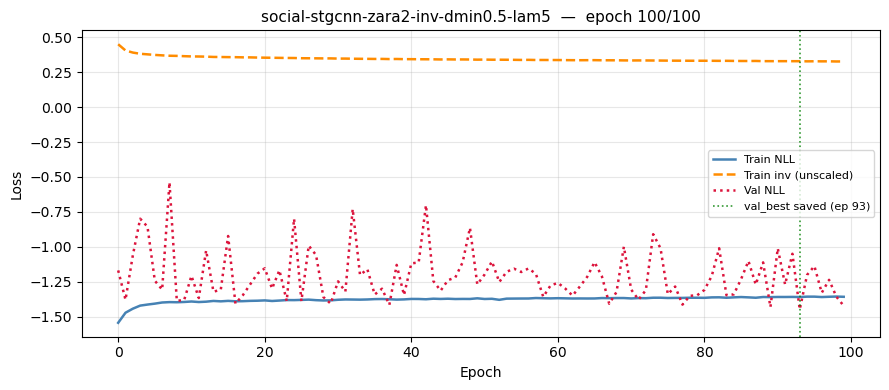

Saved  val_best (ep 93)  +  epoch_final  ->  ./finetune_other_losses_zara2_labda5_dmin0205\social-stgcnn-zara2-inv-dmin0.5-lam5

All fine-tuning runs complete.


In [11]:
all_histories = {}

for i, cfg in enumerate(CONFIGS):
    sep = '='*60
    print(f'\n{sep}')
    print(f'Config {i+1}/{len(CONFIGS)}: loss={cfg["loss_fn"]}  d_min={cfg["d_min"]}  lambda_col={cfg["lambda_col"]}')
    print(sep)
    hist = fine_tune(cfg, verbose=True)
    if hist is None:
        print(f'  Skipped {run_tag(cfg)} due to divergence.')
    else:
        all_histories[run_tag(cfg)] = hist

print('\nAll fine-tuning runs complete.')


## 10. Training curve summary (all runs)

Loss curves saved as PNGs during training.


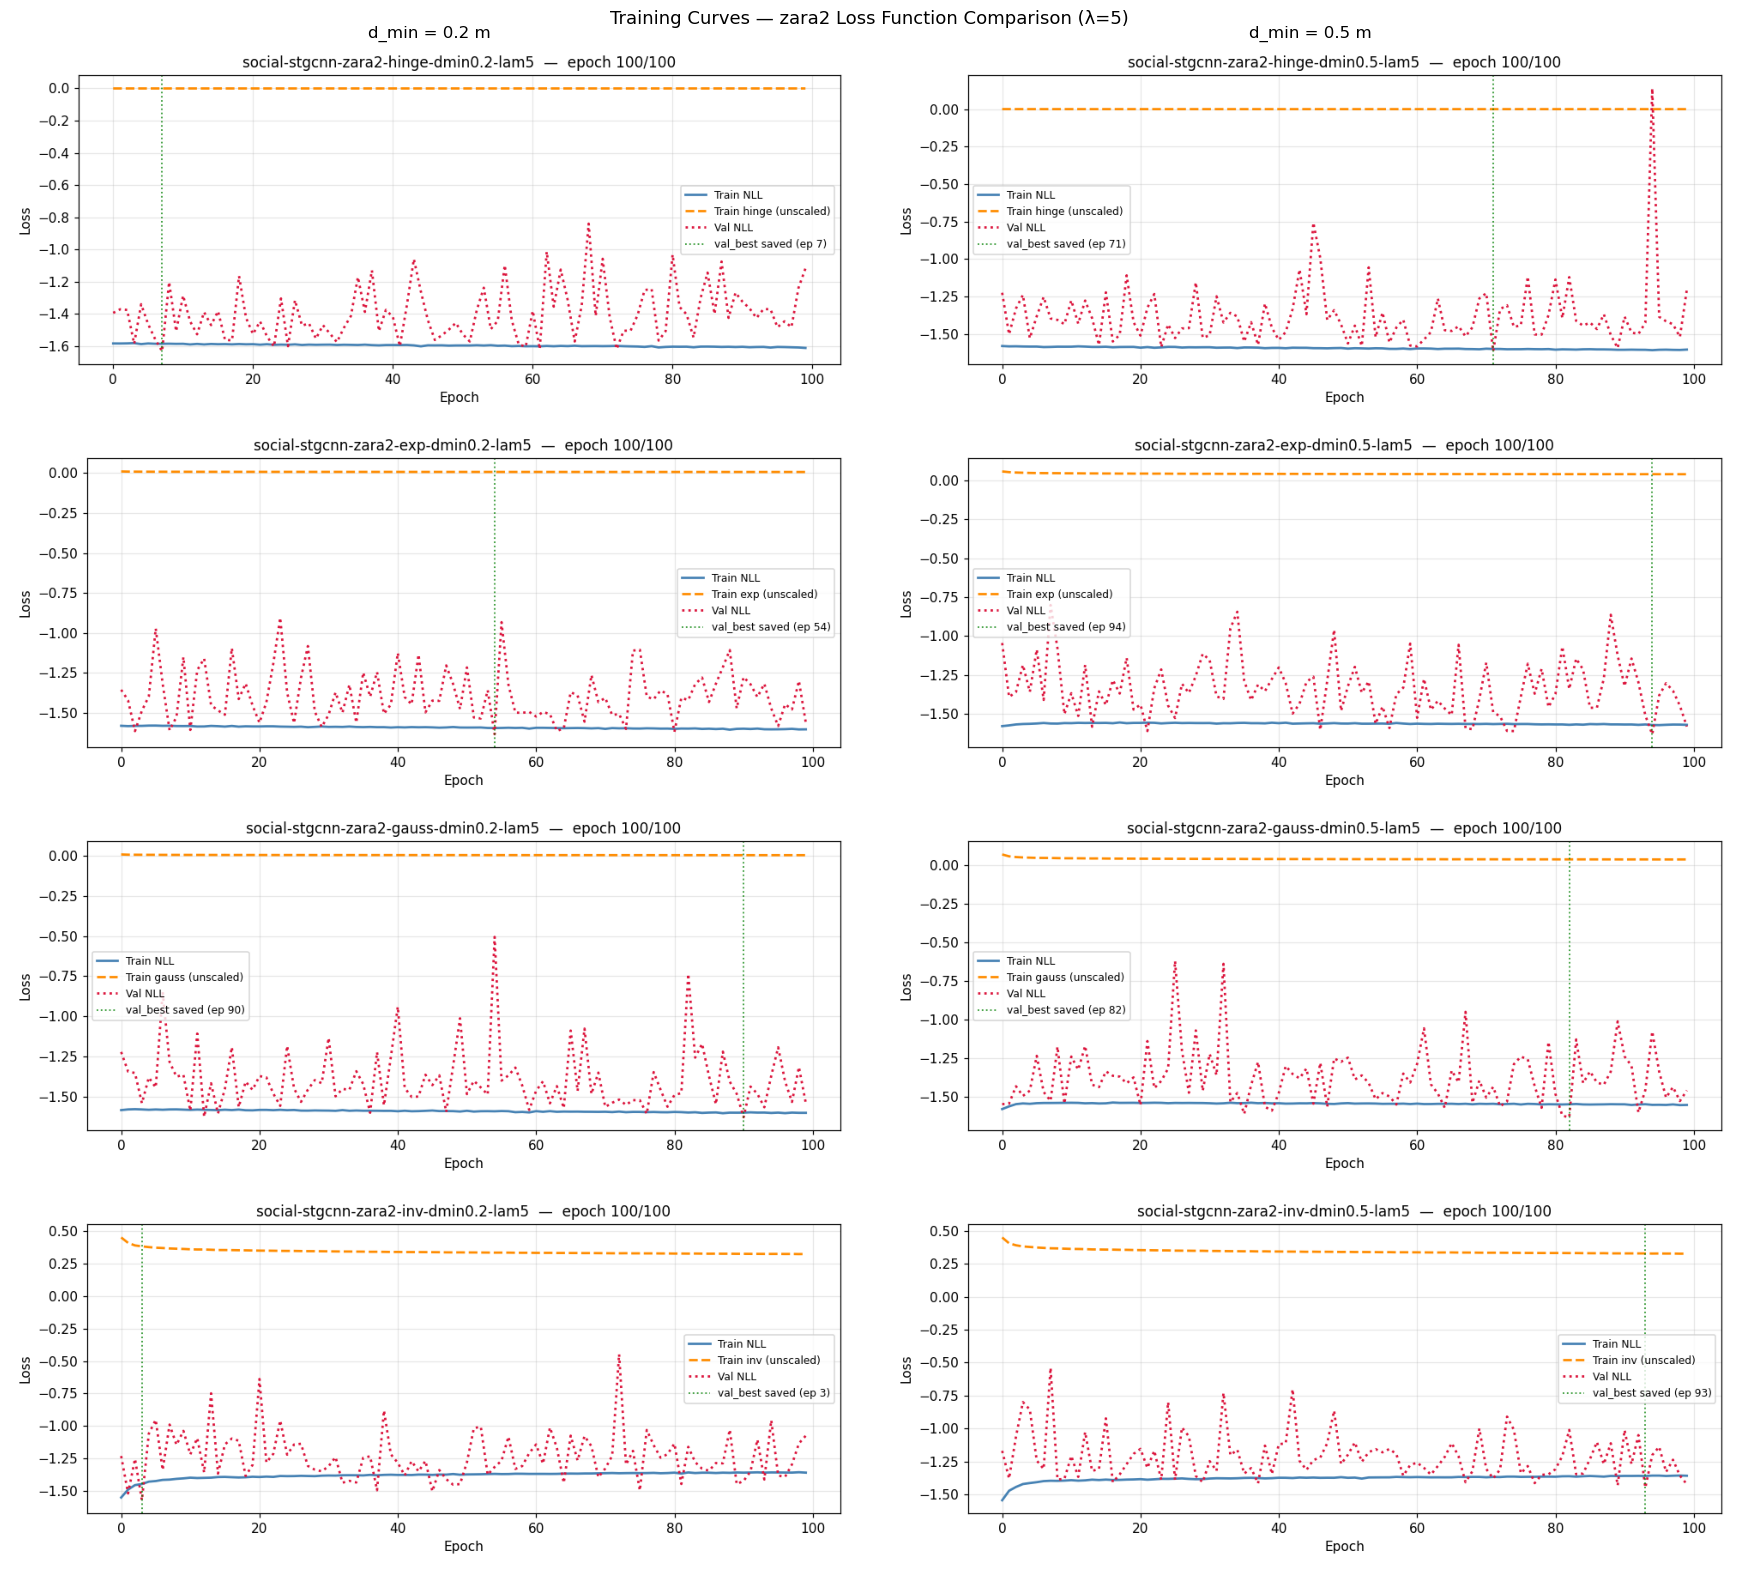

Saved ./finetune_other_losses_zara2_labda5_dmin0205\otherloss_training_curves.png


In [12]:
from matplotlib.image import imread

n_rows = len(LOSS_FN_LIST)
n_cols = len(D_MIN_LIST)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(9 * n_cols, 4 * n_rows), squeeze=False)

for row_i, loss in enumerate(LOSS_FN_LIST):
    for col_i, d_min in enumerate(D_MIN_LIST):
        cfg = {'loss_fn': loss, 'd_min': d_min, 'lambda_col': LAMBDA_LIST[0]}
        png = os.path.join(run_dir(cfg), 'training_curve.png')
        ax  = axes[row_i][col_i]
        if os.path.exists(png):
            ax.imshow(imread(png))
            ax.axis('off')
        else:
            ax.text(0.5, 0.5, f'Not found:\n{png}',
                    ha='center', va='center', transform=ax.transAxes, fontsize=8)
            ax.axis('off')
        if row_i == 0:
            ax.set_title(f'd_min = {d_min} m', fontsize=12, pad=6)
        if col_i == 0:
            ax.set_ylabel(f'{loss}', fontsize=11, labelpad=8)

fig.suptitle('Training Curves — zara2 Loss Function Comparison (λ=5)', fontsize=13)
plt.tight_layout()
out_png = os.path.join(FINETUNE_ROOT, 'otherloss_training_curves.png')
plt.savefig(out_png, dpi=120, bbox_inches='tight')
plt.show()
print('Saved', out_png)


## 11. Evaluate all checkpoints

For each config we evaluate **two** checkpoints:
- `val_best.pth`    — best NLL epoch (most accurate, least collision benefit)
- `epoch_final.pth` — last training epoch (most collision benefit, some ADE cost)

In [13]:
results = []

# ── Baseline ────────────────────────────────────────────────────────────────────────
print('Evaluating baseline ...')
r = evaluate_model(BASELINE_CKPT)
r.update({'Model': 'Baseline', 'Checkpoint': 'val_best',
          'loss_fn': None, 'd_min': None, 'lambda_col': None})
results.append(r)
print(f'  ADE={r["ADE"]:.4f}  FDE={r["FDE"]:.4f}  '
      f'ColRate_avg={r["ColRate_avg"]:.4f}  ColRate_minADE={r["ColRate_minADE"]:.4f}')

# ── Fine-tuned: both checkpoints ─────────────────────────────────────────────────
for cfg in CONFIGS:
    for ckpt_file, ckpt_label in [('val_best.pth',    'best NLL'),
                                   ('epoch_final.pth', 'final ep')]:
        path = os.path.join(run_dir(cfg), ckpt_file)
        lbl  = f'{cfg["loss_fn"].upper()} d={cfg["d_min"]} lam={cfg["lambda_col"]} [{ckpt_label}]'
        print(f'Evaluating {lbl} ...')
        r = evaluate_model(path)
        r.update({'Model': lbl, 'Checkpoint': ckpt_label,
                  'loss_fn': cfg['loss_fn'], 'd_min': cfg['d_min'], 'lambda_col': cfg['lambda_col']})
        results.append(r)
        print(f'  ADE={r["ADE"]:.4f}  FDE={r["FDE"]:.4f}  '
              f'ColRate_avg={r["ColRate_avg"]:.4f}  ColRate_minADE={r["ColRate_minADE"]:.4f}')

df = pd.DataFrame(results).set_index('Model')
for col in ['ADE','FDE','ColRate_avg','ColRate_minADE']:
    df[col] = pd.to_numeric(df[col])

base_ade = df.loc['Baseline', 'ADE']
base_fde = df.loc['Baseline', 'FDE']
base_col = df.loc['Baseline', 'ColRate_avg']
df['ΔADE']     = df['ADE']          - base_ade
df['ΔFDE']     = df['FDE']          - base_fde
df['ΔColRate']  = df['ColRate_avg'] - base_col

print('\nDone.')


Evaluating baseline ...
  ADE=0.3054  FDE=0.5008  ColRate_avg=0.4254  ColRate_minADE=0.3887
Evaluating HINGE d=0.2 lam=5 [best NLL] ...
  ADE=0.3193  FDE=0.5418  ColRate_avg=0.4109  ColRate_minADE=0.3746
Evaluating HINGE d=0.2 lam=5 [final ep] ...
  ADE=0.3494  FDE=0.5509  ColRate_avg=0.4083  ColRate_minADE=0.4017
Evaluating HINGE d=0.5 lam=5 [best NLL] ...
  ADE=0.3059  FDE=0.5131  ColRate_avg=0.4072  ColRate_minADE=0.3572
Evaluating HINGE d=0.5 lam=5 [final ep] ...
  ADE=0.3544  FDE=0.5555  ColRate_avg=0.4296  ColRate_minADE=0.4180
Evaluating EXP d=0.2 lam=5 [best NLL] ...
  ADE=0.3146  FDE=0.5218  ColRate_avg=0.4465  ColRate_minADE=0.4104
Evaluating EXP d=0.2 lam=5 [final ep] ...
  ADE=0.3069  FDE=0.5047  ColRate_avg=0.4174  ColRate_minADE=0.3735
Evaluating EXP d=0.5 lam=5 [best NLL] ...
  ADE=0.3124  FDE=0.5120  ColRate_avg=0.4328  ColRate_minADE=0.4115
Evaluating EXP d=0.5 lam=5 [final ep] ...
  ADE=0.3087  FDE=0.5034  ColRate_avg=0.4322  ColRate_minADE=0.4072
Evaluating GAUSS d=0

## 12. Results table

In [15]:
display_cols = ['Checkpoint','ADE','FDE','ColRate_avg','ColRate_minADE','ΔADE','ΔFDE','ΔColRate']
fmt = {'ADE':'{:.4f}','FDE':'{:.4f}',
       'ColRate_avg':'{:.4f}','ColRate_minADE':'{:.4f}',
       'ΔADE':'{:+.4f}','ΔFDE':'{:+.4f}','ΔColRate':'{:+.4f}'}

styled = (df[display_cols]
    .style
    .format(fmt)
    .background_gradient(subset=['ColRate_avg'], cmap='RdYlGn_r')
    .background_gradient(subset=['ADE'],         cmap='RdYlGn_r')
    .set_caption(
        'zara2 test results — val_best vs epoch_final for each config.\n'
        'val_best = best NLL checkpoint; epoch_final = last training epoch.')
)
display(styled)

,Checkpoint,ADE,FDE,ColRate_avg,ColRate_minADE,ΔADE,ΔFDE,ΔColRate
Model,,,,,,,,
Baseline,val_best,0.3054,0.5008,0.4254,0.3887,+0.0000,+0.0000,+0.0000
HINGE d=0.2 lam=5 [best NLL],best NLL,0.3193,0.5418,0.4109,0.3746,+0.0139,+0.0410,-0.0145
HINGE d=0.2 lam=5 [final ep],final ep,0.3494,0.5509,0.4083,0.4017,+0.0440,+0.0501,-0.0171
HINGE d=0.5 lam=5 [best NLL],best NLL,0.3059,0.5131,0.4072,0.3572,+0.0006,+0.0123,-0.0182
HINGE d=0.5 lam=5 [final ep],final ep,0.3544,0.5555,0.4296,0.4180,+0.0490,+0.0548,+0.0043
EXP d=0.2 lam=5 [best NLL],best NLL,0.3146,0.5218,0.4465,0.4104,+0.0092,+0.0210,+0.0211
EXP d=0.2 lam=5 [final ep],final ep,0.3069,0.5047,0.4174,0.3735,+0.0015,+0.0039,-0.0079
EXP d=0.5 lam=5 [best NLL],best NLL,0.3124,0.5120,0.4328,0.4115,+0.0070,+0.0112,+0.0075
EXP d=0.5 lam=5 [final ep],final ep,0.3087,0.5034,0.4322,0.4072,+0.0033,+0.0026,+0.0068


## 13. Tradeoff plot: Collision Rate vs ADE / FDE

- `val_best` checkpoints: **filled** markers
- `epoch_final` checkpoints: **open** markers
- Arrow shows direction val_best → epoch_final


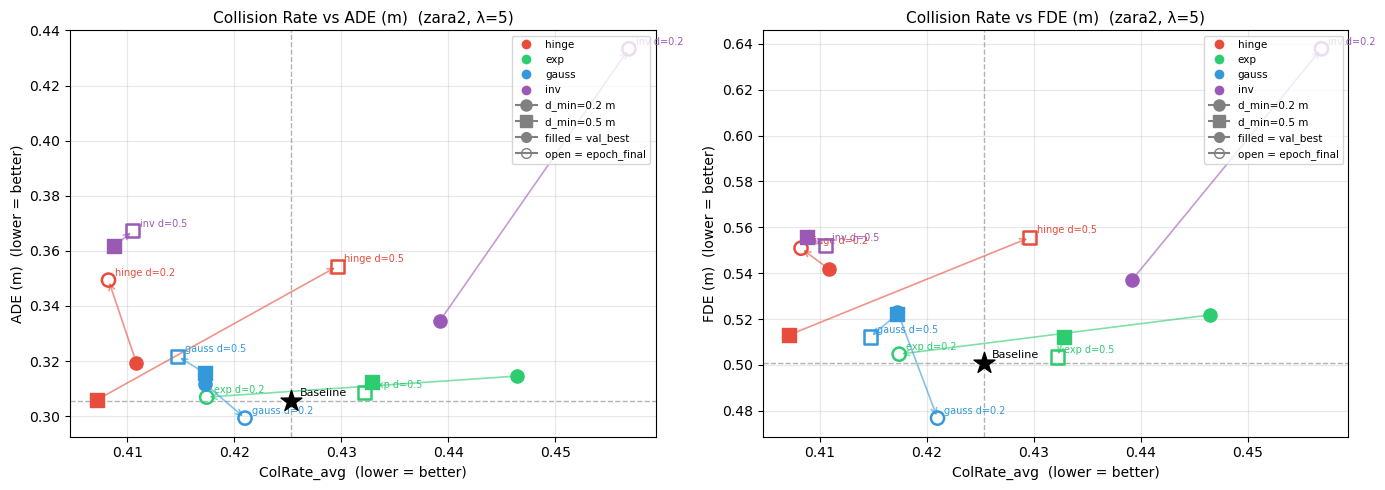

Saved ./finetune_other_losses_zara2_labda5_dmin0205\otherloss_tradeoff.png


In [16]:
# colour = loss function, marker = d_min
col_map    = {'hinge': '#e74c3c', 'exp': '#2ecc71', 'gauss': '#3498db', 'inv': '#9b59b6'}
marker_map = {0.2: 'o', 0.5: 's'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_col, y_lbl in [(axes[0], 'ADE', 'ADE (m)'), (axes[1], 'FDE', 'FDE (m)')]:

    bx = df.loc['Baseline', 'ColRate_avg']
    by = df.loc['Baseline', y_col]
    ax.axvline(bx, color='gray', linestyle='--', linewidth=1, alpha=0.6)
    ax.axhline(by, color='gray', linestyle='--', linewidth=1, alpha=0.6)
    ax.scatter([bx], [by], marker='*', s=250, color='black', zorder=6, label='Baseline')
    ax.annotate('Baseline', (bx, by), xytext=(6, 4), textcoords='offset points', fontsize=8)

    for cfg in CONFIGS:
        c   = col_map[cfg['loss_fn']]
        mk  = marker_map[cfg['d_min']]
        lbl_best  = f'{cfg["loss_fn"].upper()} d={cfg["d_min"]} lam={cfg["lambda_col"]} [best NLL]'
        lbl_final = f'{cfg["loss_fn"].upper()} d={cfg["d_min"]} lam={cfg["lambda_col"]} [final ep]'

        rx_best  = df.loc[lbl_best,  'ColRate_avg'];  ry_best  = df.loc[lbl_best,  y_col]
        rx_final = df.loc[lbl_final, 'ColRate_avg'];  ry_final = df.loc[lbl_final, y_col]

        ax.annotate('', xy=(rx_final, ry_final), xytext=(rx_best, ry_best),
                    arrowprops=dict(arrowstyle='->', color=c, lw=1.2, alpha=0.6))
        ax.scatter([rx_best],  [ry_best],  color=c, marker=mk, s=90, zorder=5)
        ax.scatter([rx_final], [ry_final], facecolors='none', edgecolors=c,
                   marker=mk, s=90, linewidths=1.8, zorder=5)
        ax.annotate(f'{cfg["loss_fn"]} d={cfg["d_min"]}',
                    (rx_final, ry_final), xytext=(5, 3),
                    textcoords='offset points', fontsize=7, color=c)

    ax.set_xlabel('ColRate_avg  (lower = better)', fontsize=10)
    ax.set_ylabel(f'{y_lbl}  (lower = better)', fontsize=10)
    ax.set_title(f'Collision Rate vs {y_lbl}  (zara2, λ=5)', fontsize=11)
    ax.grid(True, alpha=0.3)

    legend_els = (
        [Line2D([0],[0], marker='o', color='w', markerfacecolor=v,
                markersize=8, label=k) for k, v in col_map.items()] +
        [Line2D([0],[0], marker=v, color='gray',
                markersize=8, label=f'd_min={k} m') for k, v in marker_map.items()] +
        [Line2D([0],[0], marker='o', color='gray', markersize=7, label='filled = val_best'),
         Line2D([0],[0], marker='o', color='gray', markersize=7,
                fillstyle='none', label='open = epoch_final')]
    )
    ax.legend(handles=legend_els, fontsize=7.5, loc='upper right')

plt.tight_layout()
out_png = os.path.join(FINETUNE_ROOT, 'otherloss_tradeoff.png')
plt.savefig(out_png, dpi=130, bbox_inches='tight')
plt.show()
print('Saved', out_png)


## 14. Summary: best config

Find the config + checkpoint that reduces collision rate the most while keeping ΔADE < +0.05 m.

In [17]:
ADE_BUDGET = 0.05   # max allowed ADE increase over baseline

candidates = df[(df['ΔADE'] <= ADE_BUDGET) & (df.index != 'Baseline')].copy()

if candidates.empty:
    print(f'No config reduces collision rate within ΔADE <= {ADE_BUDGET} m.')
    print('Consider relaxing ADE_BUDGET or reducing FINETUNE_EPOCHS.')
else:
    best_cfg = candidates['ΔColRate'].idxmin()
    row = candidates.loc[best_cfg]
    print(f'Best config within ΔADE <= {ADE_BUDGET} m:')
    print(f'  Model       : {best_cfg}')
    print(f'  ADE         : {row["ADE"]:.4f}  (ΔADE={row["ΔADE"]:+.4f})')
    print(f'  FDE         : {row["FDE"]:.4f}  (ΔFDE={row["ΔFDE"]:+.4f})')
    print(f'  ColRate_avg : {row["ColRate_avg"]:.4f}  (ΔColRate={row["ΔColRate"]:+.4f})')
    print(f'  ColRate_minADE: {row["ColRate_minADE"]:.4f}')

Best config within ΔADE <= 0.05 m:
  Model       : HINGE d=0.5 lam=5 [best NLL]
  ADE         : 0.3059  (ΔADE=+0.0006)
  FDE         : 0.5131  (ΔFDE=+0.0123)
  ColRate_avg : 0.4072  (ΔColRate=-0.0182)
  ColRate_minADE: 0.3572


## 15. Save results & persist to Drive

In [18]:
out_csv = os.path.join(FINETUNE_ROOT, 'otherloss_results.csv')
df.to_csv(out_csv)
print('Saved', out_csv)
display(df)


Saved ./finetune_other_losses_zara2_labda5_dmin0205\otherloss_results.csv


,ADE,FDE,ColRate_avg,ColRate_minADE,Checkpoint,loss_fn,d_min,lambda_col,ΔADE,ΔFDE,ΔColRate
Model,,,,,,,,,,,
Baseline,0.305365,0.500790,0.425353,0.388708,val_best,None,NaN,NaN,0.000000,0.000000,0.000000
HINGE d=0.2 lam=5 [best NLL],0.319308,0.541782,0.410858,0.374593,best NLL,hinge,0.2,5.0,0.013943,0.040992,-0.014495
HINGE d=0.2 lam=5 [final ep],0.349393,0.550886,0.408252,0.401737,final ep,hinge,0.2,5.0,0.044028,0.050096,-0.017101
HINGE d=0.5 lam=5 [best NLL],0.305916,0.513095,0.407166,0.357220,best NLL,hinge,0.5,5.0,0.000551,0.012305,-0.018187
HINGE d=0.5 lam=5 [final ep],0.354403,0.555546,0.429642,0.418024,final ep,hinge,0.5,5.0,0.049038,0.054756,0.004289
EXP d=0.2 lam=5 [best NLL],0.314566,0.521778,0.446471,0.410423,best NLL,exp,0.2,5.0,0.009200,0.020988,0.021118
EXP d=0.2 lam=5 [final ep],0.306907,0.504684,0.417427,0.373507,final ep,exp,0.2,5.0,0.001542,0.003894,-0.007926
EXP d=0.5 lam=5 [best NLL],0.312350,0.512013,0.432845,0.411509,best NLL,exp,0.5,5.0,0.006985,0.011223,0.007492
EXP d=0.5 lam=5 [final ep],0.308696,0.503415,0.432193,0.407166,final ep,exp,0.5,5.0,0.003331,0.002625,0.006840


In [19]:
out_hist = os.path.join(FINETUNE_ROOT, 'all_histories.pkl')
with open(out_hist, 'wb') as f:
    pickle.dump(all_histories, f)
print(f'Saved training histories ({len(all_histories)} runs) -> {out_hist}')

# Colab: copy FINETUNE_ROOT to Drive if needed
# !cp -r {FINETUNE_ROOT} /content/drive/MyDrive/DLproject-Social-STGCNN/


Saved training histories (8 runs) -> ./finetune_other_losses_zara2_labda5_dmin0205\all_histories.pkl


In [20]:
# Verify all run directories were created
for cfg in CONFIGS:
    d = run_dir(cfg)
    files = os.listdir(d) if os.path.isdir(d) else ['MISSING']
    print(f'{run_tag(cfg):55s}  {files}')


social-stgcnn-zara2-hinge-dmin0.2-lam5                   ['args.pkl', 'constant_metrics.pkl', 'epoch_final.pth', 'metrics.pkl', 'training_curve.png', 'val_best.pth']
social-stgcnn-zara2-hinge-dmin0.5-lam5                   ['args.pkl', 'constant_metrics.pkl', 'epoch_final.pth', 'metrics.pkl', 'training_curve.png', 'val_best.pth']
social-stgcnn-zara2-exp-dmin0.2-lam5                     ['args.pkl', 'constant_metrics.pkl', 'epoch_final.pth', 'metrics.pkl', 'training_curve.png', 'val_best.pth']
social-stgcnn-zara2-exp-dmin0.5-lam5                     ['args.pkl', 'constant_metrics.pkl', 'epoch_final.pth', 'metrics.pkl', 'training_curve.png', 'val_best.pth']
social-stgcnn-zara2-gauss-dmin0.2-lam5                   ['args.pkl', 'constant_metrics.pkl', 'epoch_final.pth', 'metrics.pkl', 'training_curve.png', 'val_best.pth']
social-stgcnn-zara2-gauss-dmin0.5-lam5                   ['args.pkl', 'constant_metrics.pkl', 'epoch_final.pth', 'metrics.pkl', 'training_curve.png', 'val_best.pth']
soci

In [21]:
print(all_histories)

{'social-stgcnn-zara2-hinge-dmin0.2-lam5': {'train_loss': [-1.5825429734061747, -1.5827454188290764, -1.582084578626296, -1.580344624379102, -1.5865602037485909, -1.582553670686834, -1.5844178269891178, -1.5845460050246294, -1.5840202710207771, -1.584986101178562, -1.5845956416691052, -1.5886118622387158, -1.5853578448295593, -1.5885325039134306, -1.5857394933700562, -1.5872371126623714, -1.5865649265401505, -1.5880767632933224, -1.5861256403081558, -1.5877948473481571, -1.5870002963963676, -1.5901400411830229, -1.5872293009477503, -1.590948364313911, -1.5895424555329716, -1.5905613513553845, -1.5880758201374727, -1.5919763761408188, -1.5897263919605928, -1.5907958956325756, -1.5900821089744568, -1.589772476869471, -1.5919009902898003, -1.5904654089142294, -1.5911643610281103, -1.5920799164211048, -1.5899579805486344, -1.592843637746923, -1.5943881097961874, -1.5923910456545212, -1.592208529219908, -1.5924418463426477, -1.5918283953386194, -1.594507378690383, -1.600378106622135, -1.594

{'social-stgcnn-zara2-hinge-dmin0.2-lam5': {'train_loss': [-1.5825429734061747, -1.5827454188290764, -1.582084578626296, -1.580344624379102, -1.5865602037485909, -1.582553670686834, -1.5844178269891178, -1.5845460050246294, -1.5840202710207771, -1.584986101178562, -1.5845956416691052, -1.5886118622387158, -1.5853578448295593, -1.5885325039134306, -1.5857394933700562, -1.5872371126623714, -1.5865649265401505, -1.5880767632933224, -1.5861256403081558, -1.5877948473481571, -1.5870002963963676, -1.5901400411830229, -1.5872293009477503, -1.590948364313911, -1.5895424555329716, -1.5905613513553845, -1.5880758201374727, -1.5919763761408188, -1.5897263919605928, -1.5907958956325756, -1.5900821089744568, -1.589772476869471, -1.5919009902898003, -1.5904654089142294, -1.5911643610281103, -1.5920799164211048, -1.5899579805486344, -1.592843637746923, -1.5943881097961874, -1.5923910456545212, -1.592208529219908, -1.5924418463426477, -1.5918283953386194, -1.594507378690383, -1.600378106622135, -1.594094455242157, -1.5944379568099976, -1.5941389448502485, -1.5960743742830612, -1.595067963880651, -1.5949818842551287, -1.5950649836484123, -1.5935658742399776, -1.595367620973026, -1.5933151665855856, -1.59694022992078, -1.5958311207154219, -1.5993174630052902, -1.5980005544774674, -1.599941982942469, -1.5994262134327608, -1.600270590361427, -1.5980565653127783, -1.5999233512317432, -1.597777734784519, -1.5991138219833374, -1.596643188420464, -1.5994591572705437, -1.5990300494081833, -1.5987569900120007, -1.5993321362663717, -1.5988346092841204, -1.5976889974930708, -1.5995673116515665, -1.600712983047261, -1.601690849837135, -1.6039638063486885, -1.5994010532603544, -1.6072781366460465, -1.604234327288235, -1.6025562005884506, -1.6030294544556563, -1.602695272249334, -1.606278352877673, -1.6022390547920675, -1.601958692073822, -1.602632010684294, -1.604117982527789, -1.6032761405496037, -1.604709474479451, -1.6033507234909956, -1.6060490432907553, -1.6046421387616325, -1.604050808093127, -1.608067189945894, -1.6042998292866875, -1.605007199680104, -1.606301889700048, -1.607527946724611, -1.6103689670562744], 'train_nll': [-1.5826503073467928, -1.5828498601913452, -1.5821855103268343, -1.580449030679815, -1.5866611249306624, -1.5826541886610144, -1.584516868871801, -1.5846460777170517, -1.584120182430043, -1.5850842665223515, -1.5846934388665592, -1.5887107638751758, -1.5854574512032902, -1.588632716852076, -1.5858367050395292, -1.587332357378567, -1.5866586285478927, -1.5881723165512085, -1.5862221262034248, -1.5878922378315645, -1.5870931639390833, -1.5902274461353527, -1.5873267860973583, -1.5910381254027872, -1.5896369113641626, -1.5906549025984371, -1.5881674149457146, -1.5920666210791643, -1.5898141440223246, -1.5908936472500073, -1.590173553018009, -1.5898630443741293, -1.5919863792026745, -1.5905567653038923, -1.5912555876900167, -1.5921647653860205, -1.5900442179511576, -1.592928360490238, -1.5944758828948526, -1.5924778861158035, -1.5922920598703272, -1.5925234100397896, -1.5919181248720955, -1.59459309016957, -1.6004581521539127, -1.5941734945072847, -1.5945197098395403, -1.5942239130244535, -1.5961560922510483, -1.595151960849762, -1.5950665263568653, -1.595151193001691, -1.5936479217865889, -1.5954494125702803, -1.593397179070641, -1.5970203175264246, -1.5959089573691874, -1.5993976417709799, -1.5980877210112179, -1.6000201596933252, -1.5995061678044937, -1.6003536161254435, -1.5981397839153515, -1.60000299355563, -1.597856665358824, -1.5991930961608887, -1.596724222688114, -1.5995379405863144, -1.5991074197432573, -1.598839721258949, -1.5994107793359196, -1.598916975890889, -1.597769120160271, -1.5996464981752283, -1.6007906969855814, -1.6017681886168087, -1.6040395813829758, -1.5994776206858017, -1.6073550792301403, -1.6043090469696943, -1.6026375924839693, -1.6031045668265398, -1.6027715241207796, -1.6063520662924822, -1.6023154188604916, -1.6020397263414718, -1.6027090233914993, -1.6041924111983354, -1.603351891040802, -1.6047855755862068, -1.6034241073271807, -1.606125344248379, -1.604722243898055, -1.6041237676844877, -1.6081447145518135, -1.6043749556821936, -1.6050871540518368, -1.6063799717847038, -1.6076037147465874, -1.6104450085583855], 'train_col': [2.146478553132671e-05, 2.090271748463291e-05, 2.017515161616543e-05, 2.087956441113527e-05, 2.0178305342543515e-05, 2.012105575404883e-05, 1.9814639285066413e-05, 2.0028959290678304e-05, 2.0000267715444995e-05, 1.9620299380061196e-05, 1.9557905689533288e-05, 1.9786604137634105e-05, 1.992450136319402e-05, 2.002543624257669e-05, 1.944426741615376e-05, 1.9073108954698374e-05, 1.873393439917195e-05, 1.9123776061914052e-05, 1.928426220007061e-05, 1.946181047220735e-05, 1.8580806106590043e-05, 1.7478299990697825e-05, 1.949650214448732e-05, 1.7962205072977024e-05, 1.8906742431735276e-05, 1.8687132684563575e-05, 1.8318868435873062e-05, 1.8059611935474523e-05, 1.756827666266712e-05, 1.954673994345392e-05, 1.830845151155646e-05, 1.809120346800174e-05, 1.7076984824919183e-05, 1.8283178900781102e-05, 1.8253220172054545e-05, 1.697975177622164e-05, 1.7253448036439403e-05, 1.6940973169124953e-05, 1.754907998474664e-05, 1.7358884192350053e-05, 1.6718485753966996e-05, 1.6293202901686207e-05, 1.7925088821571346e-05, 1.7152177700635922e-05, 1.6007884275549097e-05, 1.580494862911805e-05, 1.6357134601254502e-05, 1.6990500666104388e-05, 1.6334641927909723e-05, 1.680498164258846e-05, 1.6915246118621915e-05, 1.724547449638896e-05, 1.6379050815457423e-05, 1.634811899427458e-05, 1.6400790922061252e-05, 1.6011049865483074e-05, 1.5584983644015773e-05, 1.6007334807000007e-05, 1.743587138073909e-05, 1.56315931074941e-05, 1.5980818876842558e-05, 1.6607000067297657e-05, 1.665174505326243e-05, 1.592836772889474e-05, 1.5787354146489044e-05, 1.587338084284377e-05, 1.6215659905035008e-05, 1.5748832177397324e-05, 1.548412207258105e-05, 1.654829393641301e-05, 1.573778463887934e-05, 1.6488417553345617e-05, 1.602643593447711e-05, 1.5840444381651384e-05, 1.554010716919198e-05, 1.547434698402546e-05, 1.51695149283756e-05, 1.534082793221066e-05, 1.5401500290328625e-05, 1.49358209936883e-05, 1.62702368965363e-05, 1.5024424770030344e-05, 1.5233548819036086e-05, 1.4750114480514586e-05, 1.5276565952316398e-05, 1.6210300667380044e-05, 1.5411151346544264e-05, 1.4886934496537245e-05, 1.515373672672842e-05, 1.52142923017142e-05, 1.4699241252374658e-05, 1.5253408184221103e-05, 1.6030316841994028e-05, 1.4593931542977397e-05, 1.55107085554525e-05, 1.5059871363037554e-05, 1.5992652994528352e-05, 1.563973604093275e-05, 1.5157225508279653e-05, 1.5204316214829519e-05], 'val_loss': [-1.3928827792406082, -1.370579481124878, -1.3746216148138046, -1.5851880311965942, -1.339247152209282, -1.4630464017391205, -1.5557180345058441, -1.6311282217502594, -1.2011728435754776, -1.5074701011180878, -1.2852023243904114, -1.4451925158500671, -1.5258181393146515, -1.388176292181015, -1.4689176380634308, -1.3822213411331177, -1.5610498189926147, -1.5630427598953247, -1.1641265824437141, -1.4237322807312012, -1.5247246026992798, -1.4456907659769058, -1.5393371880054474, -1.6017626523971558, -1.3035807758569717, -1.599678248167038, -1.3139605075120926, -1.4720618575811386, -1.458229809999466, -1.5526355504989624, -1.4692405760288239, -1.5216156840324402, -1.5746493637561798, -1.485049158334732, -1.4119040369987488, -1.1705435141921043, -1.386774018406868, -1.1291320472955704, -1.5061708092689514, -1.3744612336158752, -1.4180582910776138, -1.5996099412441254, -1.3456112146377563, -1.0589422974735498, -1.2602566927671432, -1.437988042831421, -1.5610695779323578, -1.5319725275039673, -1.4970339238643646, -1.454889178276062, -1.5256460309028625, -1.5702496469020844, -1.375181332230568, -1.236814722418785, -1.4940086007118225, -1.4419336467981339, -1.0966829061508179, -1.4386126548051834, -1.588997483253479, -1.6023606359958649, -1.3799742758274078, -1.6175417006015778, -1.0129718706011772, -1.3541628569364548, -1.1242638379335403, -1.313438132405281, -1.5703481137752533, -1.3481198996305466, -0.8389279171824455, -1.4118010103702545, -1.0571020618081093, -1.4183813482522964, -1.6178510189056396, -1.5039288103580475, -1.5023927092552185, -1.4057662338018417, -1.2509215027093887, -1.2455997914075851, -1.564765751361847, -1.5067058205604553, -1.0314155919477344, -1.3565915375947952, -1.4013858139514923, -1.5462185740470886, -1.3019735515117645, -1.1429729163646698, -1.3999984711408615, -1.0743898749351501, -1.4237943142652512, -1.2672816663980484, -1.3237857073545456, -1.3646162003278732, -1.4248822778463364, -1.3692503869533539, -1.3704495579004288, -1.4820275604724884, -1.4454413652420044, -1.4815721213817596, -1.2383833229541779, -1.116915114223957]}, 'social-stgcnn-zara2-hinge-dmin0.5-lam5': {'train_loss': [-1.575543975128847, -1.5783089855137993, -1.5779228806495667, -1.5795087919515722, -1.580158177544089, -1.580108526874991, -1.5834767187342924, -1.5827418145011454, -1.5810152327313143, -1.5811988886664896, -1.5811448062167448, -1.5787795361350565, -1.5804557169184965, -1.5828826041782604, -1.58275708731483, -1.5816146696315092, -1.5850688990424662, -1.5833298528895658, -1.582924674539005, -1.582794841598062, -1.5878778731121737, -1.5839127337231356, -1.5883452191072351, -1.5862567810451282, -1.5825949311256409, -1.5830900143174564, -1.5870594242039848, -1.5852977107552921, -1.5857582442900713, -1.5853057784192703, -1.5851283003302181, -1.588186709319844, -1.5873603680554558, -1.5871086997144364, -1.5905541952918558, -1.5865453972535974, -1.5868122823098127, -1.587800920009613, -1.5912901548778309, -1.5894660003045027, -1.5893470504704643, -1.5916347889339222, -1.58833107176949, -1.5888434403082903, -1.58899886117262, -1.5913449070032906, -1.5915226620786331, -1.5923960664693046, -1.5909964407191557, -1.5902366532998926, -1.5942705448936014, -1.59175263783511, -1.5926831750308765, -1.5938456549363977, -1.591993528253892, -1.5926904888714062, -1.5960207967197193, -1.5961014312856339, -1.5939018761410433, -1.5973778261857874, -1.593537218430463, -1.5934807482887716, -1.5943067704930025, -1.597193346304052, -1.595061694874483, -1.5949385797276217, -1.5944932103157043, -1.5971937249688541, -1.59767487820457, -1.5989544987678528, -1.5949446523890776, -1.5967671871185303, -1.5967909132733065, -1.5987435509176815, -1.5985184662482317, -1.5984340625650741, -1.5970743298530579, -1.5981101218391867, -1.5986366131726433, -1.5974801007439108, -1.6015416313620174, -1.5993079823606156, -1.600027876741746, -1.601128522087546, -1.599236835451687, -1.5984741098740523, -1.5997845179894392, -1.5998975073589998, -1.6006169634706833, -1.602427296778735, -1.6023177294170154, -1.6015137749559738, -1.6021942285930408, -1.6024597357301151, -1.605037089656381, -1.6022599479731392, -1.6015905317138224, -1.6028821854030384, -1.6035020211163689, -1.6011155878796297], 'train_nll': [-1.5804850318852592, -1.5828054968048544, -1.5822974373312557, -1.5836035994922413, -1.5842485848595114, -1.584140188553754, -1.5874601146754097, -1.5866038448670332, -1.584920139873729, -1.5850826887523426, -1.5849426143309648, -1.5825467390172623, -1.5842653197400711, -1.586545071181129, -1.586517730179955, -1.5853017147849588, -1.5887892596861894, -1.586980542715858, -1.5865985400536482, -1.5864248310818392, -1.5914450813742245, -1.5874747037887573, -1.5918955522425033, -1.5896511112942415, -1.5862110502579634, -1.5865665148286259, -1.590601079604205, -1.588789890794193, -1.5893200776156258, -1.5887539176379932, -1.588587662752937, -1.5916507244110107, -1.590843586360707, -1.5905611374798942, -1.5939777002615088, -1.589984721997205, -1.5902345671373255, -1.5911621731870316, -1.5947163525749655, -1.5929006583550398, -1.5927380288348478, -1.5950398445129395, -1.5916989831363453, -1.5922463536262512, -1.5923322474255281, -1.5946864029940437, -1.5948479105444515, -1.5957347189678865, -1.5943009467685925, -1.593529438271242, -1.5976213427150951, -1.5950375655118156, -1.5959671665640438, -1.5971910708090837, -1.5952673168743359, -1.5959742910721724, -1.5992893296129562, -1.5993941356154049, -1.5970700803925009, -1.6006460575496448, -1.5968127180548275, -1.5967281460762024, -1.597528825787937, -1.6004413997425753, -1.5981907353681677, -1.598201506278094, -1.5977408324970919, -1.600381149965174, -1.600898101049311, -1.602159889305339, -1.5981502988759209, -1.5999386836500729, -1.5999982847886927, -1.6019931155092575, -1.6016482640715206, -1.6016341903630424, -1.6001944927608265, -1.6013411003000595, -1.601800164755653, -1.6006443255087908, -1.604658975320704, -1.60246162554797, -1.6032019082237692, -1.6042856363689197, -1.60224330775878, -1.6016107026268454, -1.6029208057066973, -1.602998344337239, -1.6037791792084188, -1.6055835310150595, -1.6054180089165182, -1.6046323039952446, -1.6053325428682215, -1.6055662281372969, -1.6081406964975244, -1.6053423881530762, -1.6046285103349125, -1.6060231713687672, -1.6066065921502954, -1.6041582963045906], 'train_col': [0.000988202475983759, 0.0008992901797789861, 0.0008749175655847305, 0.0008189630949773881, 0.000818080997252015, 0.0008063569291741313, 0.0007966719602015527, 0.0007724099114592023, 0.000781005246715401, 0.0007767793089014423, 0.000759557172012351, 0.0007534067896331715, 0.0007619171143125961, 0.0007324871120919637, 0.0007521133092642926, 0.0007374322757480995, 0.0007440941819154165, 0.0007301296847050681, 0.000734785825068898, 0.0007260016076650252, 0.0007134376458399108, 0.0007123965222169371, 0.0007100533351630849, 0.0006788847522864886, 0.0007232209027279168, 0.0006952990284737418, 0.000708333877435721, 0.0006984421240357572, 0.0007123855860246455, 0.0006896222321837045, 0.0006918674454722992, 0.0006927926648024688, 0.000696658220155822, 0.0006904876585501959, 0.0006847237835994319, 0.0006878678549957625, 0.0006844670210471924, 0.0006722511590102359, 0.0006852463942349833, 0.000686943023431334, 0.0006782054175239275, 0.0006810365080395166, 0.0006735667925300624, 0.0006805780850460424, 0.0006666849367320538, 0.0006682977571686291, 0.0006650643053409807, 0.0006677161162609563, 0.0006609066228574032, 0.0006585656990543665, 0.0006701714746133588, 0.0006570006123237202, 0.0006567929624853766, 0.0006690995771136574, 0.0006547474750892862, 0.0006567543571102707, 0.0006536967052585062, 0.0006585275336606976, 0.0006336460869266268, 0.0006536507896859856, 0.0006550797192818101, 0.0006494775323731386, 0.0006444045643815223, 0.0006496075280558537, 0.000625803554773002, 0.000652571433045737, 0.0006495205726584091, 0.0006374940284705885, 0.0006446391104391831, 0.0006410693886744626, 0.0006411110349718536, 0.0006342861845897621, 0.0006414403683533344, 0.0006499012678806834, 0.0006259650673361166, 0.0006400419310118784, 0.0006240277263500235, 0.0006462257913560333, 0.0006327359896043644, 0.0006328177525360576, 0.0006234650585718234, 0.0006307495915440514, 0.0006348032072898658, 0.0006314606066820595, 0.0006012903588057003, 0.0006273372341906104, 0.0006272716752445215, 0.000620154247906826, 0.0006324278870392043, 0.0006312361819094376, 0.0006200297057683416, 0.0006237104081425487, 0.0006276576177162282, 0.0006213013830882333, 0.0006207240238676176, 0.0006164970314678024, 0.0006075947552316767, 0.0006281766811084441, 0.0006209473478306524, 0.0006085482754689805], 'val_loss': [-1.225025162100792, -1.502827912569046, -1.3300009369850159, -1.2392645478248596, -1.5285407304763794, -1.3818518817424774, -1.2527251243591309, -1.3966012746095657, -1.4061418026685715, -1.4348974227905273, -1.2755544781684875, -1.4314295649528503, -1.2771293371915817, -1.3941499590873718, -1.574470341205597, -1.2222843915224075, -1.5502144396305084, -1.5052627325057983, -1.1089590042829514, -1.421013206243515, -1.5109727382659912, -1.3252474665641785, -1.233269840478897, -1.5876220166683197, -1.4357973635196686, -1.527333527803421, -1.463291883468628, -1.461337387561798, -1.1552376598119736, -1.5253381133079529, -1.5090199410915375, -1.2484756857156754, -1.4236681908369064, -1.358890026807785, -1.3834367841482162, -1.5512930154800415, -1.4214735627174377, -1.573687493801117, -1.2964827418327332, -1.458543986082077, -1.5399642288684845, -1.486504226922989, -1.3340743780136108, -1.0695827305316925, -1.3683562725782394, -0.7575311046093702, -0.9942134246230125, -1.4071784317493439, -1.3412042558193207, -1.435804933309555, -1.5634774267673492, -1.4442383348941803, -1.580134004354477, -1.0557241798378527, -1.5220002233982086, -1.3562906384468079, -1.557790994644165, -1.4570554196834564, -1.4051283597946167, -1.5776590704917908, -1.5828802287578583, -1.5368331372737885, -1.486783117055893, -1.2632467299699783, -1.4746745228767395, -1.4798066020011902, -1.4479060173034668, -1.5164939165115356, -1.4555665254592896, -1.262744590640068, -1.2275531068444252, -1.6154531240463257, -1.3341187238693237, -1.3084196597337723, -1.4534962475299835, -1.4420742690563202, -1.1168751046061516, -1.5031923055648804, -1.50448477268219, -1.3739942610263824, -1.1364465579390526, -1.3943170607089996, -1.1206157505512238, -1.4130089730024338, -1.444368153810501, -1.4236088395118713, -1.4671626687049866, -1.3680569231510162, -1.5066784918308258, -1.5942499041557312, -1.3840753436088562, -1.4903140664100647, -1.5007968842983246, -1.4251006245613098, 0.13872555270791054, -1.3852237313985825, -1.4154208153486252, -1.4351256489753723, -1.5199934542179108, -1.2051734775304794]}, 'social-stgcnn-zara2-exp-dmin0.2-lam5': {'train_loss': [-1.5293916148297928, -1.5363952307140125, -1.537003359373878, -1.5378472980330973, -1.5366879806799048, -1.537710263448603, -1.5389159812646753, -1.5393255843835718, -1.5412051186842077, -1.5419672517215504, -1.5417929291725159, -1.5453049645704382, -1.544966641594382, -1.5420537626042086, -1.5435145322014303, -1.5465858613743502, -1.5424599437152637, -1.5474468048881083, -1.5451518051764543, -1.5460477260982288, -1.5465118183809168, -1.545545872519998, -1.5458781017976648, -1.5475283615729387, -1.5487034215646631, -1.549059906426598, -1.5480619949453018, -1.5517888524953056, -1.5497106313705444, -1.5474910736083984, -1.550122552058276, -1.5497635883443497, -1.5504591920796562, -1.5481902606347029, -1.5508482070530163, -1.5519539889167338, -1.550467130015878, -1.5525471743415384, -1.552261282415951, -1.5545806499088513, -1.5526479973512537, -1.5540326938909643, -1.5522955095066744, -1.5535977728226606, -1.5530996848555172, -1.5541396000806023, -1.5559040483306437, -1.5548643399687374, -1.5520156306378983, -1.555195475325865, -1.555532322210424, -1.5554600638501785, -1.5553414365824532, -1.5580820581492256, -1.5591147962738485, -1.5580338660408468, -1.5568707900888779, -1.558131053167231, -1.5574681793942171, -1.5626441906480228, -1.557336498709286, -1.5575753275085897, -1.558236868942485, -1.5593242119340336, -1.5601483443204094, -1.559640463660745, -1.5589098614804886, -1.5597939666579752, -1.561712755876429, -1.5598198315676521, -1.5644034042077906, -1.5599171308910145, -1.561035882024204, -1.5606859431547278, -1.5626567356726702, -1.562706775525037, -1.5611854055348564, -1.5618976003983442, -1.563422069830053, -1.5629058024462532, -1.5650436387342566, -1.5630232200903051, -1.563347125754637, -1.5622516730252434, -1.5654638970599455, -1.5637938275056726, -1.5662193123032064, -1.5641471007291008, -1.570597743286806, -1.5652070080532747, -1.5639807196224438, -1.5660652413087732, -1.5636335926897384, -1.567659202743979, -1.568218452088973, -1.5678697263493258, -1.5669983835781323, -1.5651296622612898, -1.569126143175013, -1.5684470148647534], 'train_nll': [-1.580186310936423, -1.582227629773757, -1.5808027000988232, -1.5806561638327206, -1.578959377372966, -1.578836788149441, -1.5803368091583252, -1.5798441522261675, -1.5816038426230936, -1.5818889386513655, -1.5814227356630213, -1.584735681028927, -1.5843993916231043, -1.5808866164263558, -1.5825799878905802, -1.58518626760034, -1.5811226297827328, -1.5856013227911556, -1.583446236217723, -1.584238466094522, -1.5843734530841602, -1.5833446418537813, -1.5834393361035515, -1.5852737952681148, -1.585942871430341, -1.5868140669430004, -1.585554557688096, -1.5890652887961443, -1.5870647745973923, -1.5846022122046526, -1.5871457527665531, -1.5864772270707523, -1.587318851667292, -1.5848763760398417, -1.587602369925555, -1.5885867231032427, -1.5872248165747698, -1.5889593152438892, -1.5888356987167807, -1.5911339801900528, -1.5890568319488974, -1.5903716052279753, -1.5884328694904553, -1.5895584856762606, -1.5889237523078918, -1.5900395232088425, -1.5919215573984034, -1.5905688019359814, -1.5878432989120483, -1.5910284939934225, -1.5913014832664938, -1.5911022249390097, -1.5907258952365202, -1.5937785085509806, -1.594508072909187, -1.593589491703931, -1.5923096818082474, -1.5936744142981136, -1.5926837675711687, -1.598054959493525, -1.5926856012905346, -1.592712451429928, -1.5934015337158651, -1.5944687829298132, -1.5952499929596395, -1.5946189655977137, -1.594028791960548, -1.5947666764259338, -1.5964291481410755, -1.5947904376422657, -1.5994813512353336, -1.5945538492763744, -1.596104316851672, -1.59542276578791, -1.597310935749727, -1.5976248979568481, -1.595911492319668, -1.5965938007130343, -1.5979386497946346, -1.5976908417309033, -1.59956772888408, -1.5974821413264555, -1.5978592073216158, -1.5966671354630415, -1.5998384636991165, -1.5984482344459086, -1.600630711106693, -1.5986343692330753, -1.6046635508537292, -1.5995501946000492, -1.5984237369369059, -1.6002908278914059, -1.5977592818877275, -1.601920972852146, -1.6024465245359085, -1.6020973149467916, -1.6012088025317472, -1.599292450091418, -1.6029677461175358, -1.6024203440722298], 'train_col': [0.010158943532801726, 0.009166477275464465, 0.00875985051286133, 0.00856178141582538, 0.008454305599169695, 0.008225332671666847, 0.00828416396261138, 0.008103712790590875, 0.008079732631278388, 0.007984347367549645, 0.007925940677523613, 0.007886143538224347, 0.007886551868389635, 0.007766597671434283, 0.007813101004370871, 0.007720088449252003, 0.00773253313758794, 0.007630911491373006, 0.007658889120006386, 0.007638162084142952, 0.007572301882593071, 0.007559742011568125, 0.007512259844909696, 0.007549098665442537, 0.0074478980865986906, 0.0075508444296086535, 0.007498529438367661, 0.007455262465073782, 0.007470823495703585, 0.007422241984921343, 0.007404625771895927, 0.007342737592647181, 0.0073719105190213985, 0.007337246774969732, 0.007350851466660114, 0.007326559560811695, 0.007351555478046922, 0.007282410625039655, 0.007314865093897371, 0.007310638094649595, 0.007281758890980307, 0.0072678048437570825, 0.007227477713433259, 0.007192139993147815, 0.007164809058475143, 0.0071799908079864345, 0.007203521480893388, 0.0071408864494194, 0.0071655384484021105, 0.0071666098254568435, 0.007153824519585161, 0.007128406987142037, 0.0070769015754408695, 0.0071392602643326804, 0.007078692645711058, 0.007111128282678478, 0.007087799665682456, 0.007108663619660279, 0.007043095291866099, 0.007082157316343749, 0.00706978262785603, 0.00702741091577884, 0.007032905664185391, 0.007028926958275192, 0.007020330837215571, 0.006995705915067126, 0.007023794261519523, 0.006994573152897989, 0.006943251033697058, 0.006994125734576408, 0.007015585159773336, 0.0069273420719101145, 0.007013702326837708, 0.006947366507066523, 0.006930832230650327, 0.006983596119372284, 0.006945209646159235, 0.006939281517749324, 0.006903308608076151, 0.006957027869408622, 0.006904831019175404, 0.0068917885724016845, 0.006902418674572426, 0.006883110809961662, 0.006874920800328255, 0.006930888233268086, 0.006882230956655215, 0.006897467941812733, 0.006813176428241765, 0.006868651876335635, 0.006888607133399038, 0.006845087333417991, 0.006825132405056673, 0.006852387669770157, 0.00684560216305887, 0.0068455110577976, 0.006842064575346953, 0.006832563044393764, 0.0067683287950999595, 0.006794633809477091], 'val_loss': [-1.3551001250743866, -1.4208013713359833, -1.6133487522602081, -1.4854973256587982, -1.3957756906747818, -0.9718321952968836, -1.3166278898715973, -1.6081358790397644, -1.524605929851532, -1.1504202708601952, -1.6062271893024445, -1.2327406704425812, -1.1595421731472015, -1.4510664343833923, -1.48411363363266, -1.511073261499405, -1.094432808458805, -1.4129428267478943, -1.3155614882707596, -1.4532947540283203, -1.5614099204540253, -1.432568684220314, -1.1909859329462051, -0.9048808664083481, -1.3723082393407822, -1.563503235578537, -1.2808251529932022, -1.0816922932863235, -1.4914214611053467, -1.5877881348133087, -1.5108872652053833, -1.3713501989841461, -1.4986272752285004, -1.3233451843261719, -1.5609415173530579, -1.2468607351183891, -1.3989262133836746, -1.2440536618232727, -1.5052940249443054, -1.446900725364685, -1.1249979995191097, -1.400375708937645, -1.4461936056613922, -1.1348979137837887, -1.4960386455059052, -1.4230158627033234, -1.424186110496521, -1.2027642130851746, -1.3193070441484451, -1.4756668508052826, -1.2152281254529953, -1.52817040681839, -1.5344833433628082, -1.35786734521389, -1.6332282721996307, -0.9322559460997581, -1.3232919871807098, -1.497683972120285, -1.4993521571159363, -1.4931866824626923, -1.5223145484924316, -1.4938035011291504, -1.507371425628662, -1.6126740276813507, -1.5961326360702515, -1.3701004385948181, -1.3907373547554016, -1.554607093334198, -1.2628057152032852, -1.432238519191742, -1.405974566936493, -1.5133351385593414, -1.5064610242843628, -1.6000083982944489, -1.1101237498223782, -1.1048494316637516, -1.398212969303131, -1.4140918552875519, -1.3591547310352325, -1.382831409573555, -1.6179084181785583, -1.4052684307098389, -1.4196156859397888, -1.3195200115442276, -1.27865831553936, -1.4312251061201096, -1.3169535100460052, -1.2139684408903122, -1.1067515015602112, -1.471769630908966, -1.2758522480726242, -1.3203303664922714, -1.4007720798254013, -1.317431017756462, -1.4719018638134003, -1.58186537027359, -1.4456250071525574, -1.4778697788715363, -1.2992929071187973, -1.5614604949951172]}, 'social-stgcnn-zara2-exp-dmin0.5-lam5': {'train_loss': [-1.2940950043061201, -1.3115533555255217, -1.31800755332498, -1.3217256840537577, -1.3272593827808605, -1.3283426621380974, -1.3278844181229086, -1.3325435098479776, -1.333888078437132, -1.3339745262089897, -1.3352402308407951, -1.3336289244539596, -1.336820546318503, -1.3368533744531519, -1.3382140222717733, -1.3397488453808952, -1.3418873899123247, -1.3397983032114364, -1.3430857763570898, -1.3434234612128313, -1.342121744857115, -1.3408048924277811, -1.3440784180865568, -1.3468851061428295, -1.3459629451527315, -1.3459570618236767, -1.3475641222561108, -1.3477323476006002, -1.3474870604627274, -1.3507723632980795, -1.3488478730706608, -1.3537592011339523, -1.35179883592269, -1.3526526899898754, -1.3500054583829992, -1.350012011387769, -1.3524494837312138, -1.351733477676616, -1.3536125737078049, -1.3520331242505241, -1.3527978693737703, -1.3517498093492843, -1.3561188648728764, -1.3567430341944975, -1.3545385423828573, -1.3555370499106014, -1.358256171731388, -1.3568662229706259, -1.3558994742000805, -1.3588856774217941, -1.3584023223203772, -1.3570305459639604, -1.359792660264408, -1.3605843361686258, -1.3593900799751282, -1.3599650368970984, -1.3610971955692066, -1.357994440723868, -1.3605166217860054, -1.3630068267092985, -1.361952353926266, -1.362952958135044, -1.3642646985895492, -1.362688373116886, -1.3631443030693953, -1.363982617855072, -1.3637328954303967, -1.3646992725484512, -1.364496697397793, -1.3650747958351583, -1.364419979207656, -1.3659974266501034, -1.3650215829119963, -1.3650745819596684, -1.3664008519228767, -1.3659526740803438, -1.3658274377093595, -1.3684589126530815, -1.368961008156047, -1.3685443857136894, -1.3701162268133724, -1.3693580662502962, -1.3726296249557943, -1.3695723870221306, -1.371958010336932, -1.3681240257094889, -1.3694207983858444, -1.3689052006777596, -1.3701752424240112, -1.3704760565477259, -1.3713090419769287, -1.37076476391624, -1.3749302415286793, -1.3713491664213293, -1.3742566844996285, -1.3762784109396093, -1.3745129599290735, -1.3718852085225723, -1.3733271255212671, -1.3749054565149195], 'train_nll': [-1.5795071966507856, -1.574713086380678, -1.568725452703588, -1.565966767423293, -1.5647890041856205, -1.562660680097692, -1.5593958987909204, -1.5627839986015768, -1.5633021663216984, -1.5600545862141777, -1.560558350647197, -1.5584109039867626, -1.5593590806512272, -1.558715069995207, -1.5592398433124317, -1.5586765969500822, -1.5609357146655811, -1.5560054708929623, -1.560820856515099, -1.5588670372962952, -1.5586961297427906, -1.5572746431126314, -1.5581329640220194, -1.562151519691243, -1.5596781618454878, -1.5579566990627962, -1.5599376874811508, -1.559208838378682, -1.559854318113888, -1.5600260776631973, -1.559770710328046, -1.5635176511371838, -1.5609467520433313, -1.5612724774024065, -1.5592064261436462, -1.558372041758369, -1.5606288874850553, -1.5606488269918106, -1.5618242586360258, -1.5575580421616049, -1.5606682510936962, -1.5576048914123983, -1.5638252075980692, -1.5626644807703354, -1.5616142784847933, -1.5608664260191076, -1.5639881877338184, -1.562258797533372, -1.5601438283920288, -1.5628118690322428, -1.56314138805165, -1.5607135576360367, -1.5639269632451676, -1.5639657132765825, -1.5632266402244568, -1.5629225408329683, -1.5643745695843416, -1.5594958172124975, -1.5630288755192476, -1.5657999831087448, -1.563732031513663, -1.5651159076129688, -1.5657380118089563, -1.5641765278928421, -1.5649215123232674, -1.5654034228885876, -1.564642040168538, -1.5656837189898771, -1.565472778152017, -1.5659800347159891, -1.5649601711946375, -1.566454613910002, -1.5653965928975273, -1.5645480471498825, -1.5666404296370113, -1.5659658838720882, -1.5659195991123425, -1.5676489612635445, -1.568486883359797, -1.5679916353786694, -1.5687097065589006, -1.5686725237790276, -1.5709094299989588, -1.5684210973627426, -1.5702044858652002, -1.5663977054988636, -1.5674888982492334, -1.5660955940975863, -1.5684167006436516, -1.5684402549968046, -1.5691249440698063, -1.5688966267249163, -1.5712202016045065, -1.5688875633127548, -1.5722415973158443, -1.572906732559204, -1.5709426227737875, -1.5694250359254724, -1.569715342100929, -1.571291916510638], 'train_col': [0.05708243675968226, 0.052631968303638345, 0.050143589649130314, 0.04884824452593046, 0.0475059146171107, 0.04686358998365262, 0.04630227934788255, 0.04604810344822267, 0.045882814399459786, 0.04521605328601949, 0.04506363664918086, 0.044956375461290866, 0.04450771026313305, 0.044372348717468625, 0.04420516804298934, 0.04378550696898909, 0.04380967281758785, 0.04324142470517579, 0.043547028237405944, 0.04308871223646052, 0.04331487307653708, 0.04329396170728347, 0.04281089465846034, 0.04305329480591942, 0.04274303707129815, 0.042399932356441725, 0.04247472150360837, 0.0422953022096087, 0.04247348613160498, 0.04185073121505625, 0.042184563134523, 0.04195172350634547, 0.04182958252289716, 0.04172397656914066, 0.04184016037513228, 0.04167200077105971, 0.041635857128045135, 0.0417830581393312, 0.041642327628591484, 0.041104983428821844, 0.041574062779545784, 0.04117101551417042, 0.04154128548415268, 0.041184291900957334, 0.0414151433197891, 0.041065892095074934, 0.04114639967241708, 0.04107854701578617, 0.040848871035610926, 0.04078526214203414, 0.04094781682771795, 0.04073662584757104, 0.04082687396337004, 0.040676260367035866, 0.04076734689228675, 0.04059147922431722, 0.04065546426264679, 0.04030029333251364, 0.04050247097278342, 0.040558626875281334, 0.040355925941291976, 0.04043259756530032, 0.040294663323199045, 0.04029764037798433, 0.0403554759481374, 0.04028415636104696, 0.04018181518596761, 0.04019689735244302, 0.04019523258594906, 0.04018106114338426, 0.040108042933485084, 0.040091426714378244, 0.040075014290564204, 0.039894682957845574, 0.04004791630979847, 0.04000265195089228, 0.040018458795898104, 0.03983802260721431, 0.039905192440046984, 0.039889446514494276, 0.03971869991544415, 0.03986290119150106, 0.03965598903596401, 0.03976974230917061, 0.039649287567419166, 0.03965473394183552, 0.03961360881872037, 0.039438101956072974, 0.03964828020509552, 0.0395928390104981, 0.03956317090812851, 0.03962639050886912, 0.039257980554419404, 0.03950769519981216, 0.03959699194220936, 0.039325639057685345, 0.03928587311769233, 0.039507955422296244, 0.03927766838494469, 0.03927730823702672], 'val_loss': [-1.045454628765583, -1.3920794427394867, -1.3600983321666718, -1.1862939298152924, -1.359430879354477, -1.086911678314209, -1.4112792611122131, -0.8012944683432579, -1.0797417238354683, -1.5027020275592804, -1.3681435734033585, -1.5139750242233276, -1.1863398626446724, -1.5834377110004425, -1.3561690300703049, -1.444347769021988, -1.2833629995584488, -1.3698597252368927, -1.1407293379306793, -1.473411738872528, -1.440805733203888, -1.61109858751297, -1.335748091340065, -1.215425655245781, -1.4480701088905334, -1.5274380147457123, -1.307396873831749, -1.3667701482772827, -1.2565353065729141, -1.114695442840457, -1.1547383815050125, -1.3887890577316284, -1.4044414460659027, -0.9515604078769684, -0.844538751989603, -1.2891098856925964, -1.413371205329895, -1.3127637654542923, -1.35481096804142, -1.276319369673729, -1.2024503499269485, -1.3035359382629395, -1.498828500509262, -1.4355556964874268, -1.2955429702997208, -1.2618144154548645, -1.604202687740326, -1.2885770946741104, -0.9599151210859418, -1.481975644826889, -1.3225086778402328, -1.19872584939003, -1.3653823882341385, -1.291817992925644, -1.565165251493454, -1.453616589307785, -1.591693252325058, -1.374862477183342, -1.3323684334754944, -1.0489973239600658, -1.5260080099105835, -1.2753845900297165, -1.4751115441322327, -1.4166751503944397, -1.4666840136051178, -1.5085076689720154, -1.0568537474609911, -1.592248022556305, -1.5994000434875488, -1.4060918986797333, -1.1713116466999054, -1.4898033142089844, -1.5164324045181274, -1.6102969944477081, -1.6112197041511536, -1.3899689018726349, -1.178504228591919, -1.3710959702730179, -1.2112876325845718, -1.4574842751026154, -1.3730974793434143, -1.068388931453228, -1.3415591269731522, -1.145313385874033, -1.2160858362913132, -1.4616051018238068, -1.460840791463852, -1.2726424932479858, -0.8640789091587067, -1.1263143680989742, -1.3228407949209213, -1.1451646015048027, -1.2975086867809296, -1.5107774436473846, -1.6318085491657257, -1.3819709718227386, -1.3036331683397293, -1.3523791134357452, -1.4486810863018036, -1.5820065438747406]}, 'social-stgcnn-zara2-gauss-dmin0.2-lam5': {'train_loss': [-1.5439818150856917, -1.547261911280015, -1.5476766439045178, -1.550339937210083, -1.5536925336893868, -1.552062872578116, -1.5551233081256641, -1.553595227353713, -1.5534974161316366, -1.5555289422764498, -1.5575453428661121, -1.5558898098328535, -1.5576565931825077, -1.5588565503849703, -1.5602200066342073, -1.5577915380982792, -1.5604311683598686, -1.5573197953841265, -1.5621619505040787, -1.5623969891492058, -1.5602320607970743, -1.5600245630039888, -1.5621046213542713, -1.5602630727431352, -1.5624786089448368, -1.561023028457866, -1.5652345734484054, -1.5656052757711971, -1.564901607878068, -1.565187997677747, -1.5657982054878683, -1.5671001988298752, -1.5631558369187748, -1.5670792740934036, -1.5655525572159712, -1.5670741025139303, -1.567218994393068, -1.5672202460906084, -1.5682597335647135, -1.5679950679049772, -1.571013685534982, -1.5679722112767838, -1.5709319149746614, -1.5702402907259323, -1.5684556996121126, -1.5665373556754167, -1.5701341734212988, -1.5703791485113257, -1.5704960682812859, -1.5731574612505295, -1.5685813041294323, -1.5737376318258398, -1.5715196272906136, -1.5710362476461075, -1.5727477038607878, -1.570362322470721, -1.571580708026886, -1.5777771648238688, -1.5759109924821293, -1.579972926308127, -1.571518575443941, -1.5754532288102543, -1.5716137149754692, -1.5755124372594498, -1.574234433033887, -1.5749028956188875, -1.5744607343393213, -1.5755220160764807, -1.5762664956205032, -1.5761707635486828, -1.5756594573750216, -1.5778924191699308, -1.5745442159035627, -1.5786097330205582, -1.5767365483676685, -1.5771272988880383, -1.5783118886106156, -1.5777538278523613, -1.5789373832590439, -1.5792982788646923, -1.5774840747608858, -1.5786968574804419, -1.5810569629949682, -1.5793944351813372, -1.5836218630566317, -1.5814902291578405, -1.5805132950053495, -1.5854283991981954, -1.5821210847181433, -1.5823660738327925, -1.582067089922288, -1.5802199560053207, -1.5818657875061035, -1.5815783318351297, -1.5841303152196549, -1.582015500349157, -1.5854042908724617, -1.5819689140600317, -1.5835605964941137, -1.5837051903500277], 'train_nll': [-1.5843361931688644, -1.5800885172451244, -1.5786690711975098, -1.5802013313069063, -1.5823121982462265, -1.5803903621785782, -1.5820937717662138, -1.5801791934406055, -1.5798605224665474, -1.5813959872021395, -1.5830737913356108, -1.5811236711109387, -1.5824505406267502, -1.5835019735728992, -1.5845953085843254, -1.5819098844247705, -1.5841744086321663, -1.5809995461912716, -1.5852917608092814, -1.5858837295981014, -1.5830810876453625, -1.5829314764808207, -1.5848557072527267, -1.5824188975726856, -1.5848908564623665, -1.5835316391552197, -1.5875222998506882, -1.587778042344486, -1.5864775917109322, -1.587162130019244, -1.5875152384533602, -1.5887974290286793, -1.584486912278568, -1.5885449788149666, -1.5868721709531897, -1.5882505494005539, -1.5882617550737717, -1.5884083158829634, -1.5890654220300562, -1.5889003171640284, -1.5914857317419613, -1.5884043889887192, -1.5915293237742256, -1.5906847399823807, -1.58890502242481, -1.586919153437895, -1.5904331943568062, -1.5903270174475277, -1.5908178581910974, -1.593279761426589, -1.5885769794968998, -1.5936119907042559, -1.5913110831204582, -1.5910334131296944, -1.5917966295691097, -1.5902316324851091, -1.5912854040370268, -1.5973886111203361, -1.5956887252190535, -1.5988101889105404, -1.5909784050548779, -1.5948270384003134, -1.5908286641625797, -1.59491186282214, -1.5934457288068884, -1.5940105389146244, -1.5937588039566488, -1.5946736651308395, -1.5948822568444645, -1.5953164240893196, -1.594647179631626, -1.5967668294906616, -1.5934865334454704, -1.5974739053670097, -1.5955407970091875, -1.5956827752730425, -1.597148804103627, -1.5960835078183342, -1.5976200103759766, -1.597972119555754, -1.595934369984795, -1.5971114530282862, -1.5995578730807585, -1.5978278587846195, -1.6019606905824997, -1.5999656074187334, -1.5989305973052979, -1.6037823592915255, -1.6003452960182638, -1.6005265291999369, -1.6002864732461817, -1.5983621513142305, -1.6000032179495867, -1.5997317573603462, -1.6022355556488037, -1.6001652899910421, -1.6034415574634777, -1.5999964054893046, -1.6015115275102503, -1.6015198090497185], 'train_col': [0.008070895475718905, 0.006565341150716823, 0.006198502803111777, 0.0059723050525302395, 0.005723946029320359, 0.005665513577268404, 0.005394100910052657, 0.005316801396582057, 0.005272629191441571, 0.005173454923993524, 0.005105695495491519, 0.005046769257580095, 0.004958819337737034, 0.004929092534653404, 0.0048750920275993205, 0.004823693971368758, 0.004748637548319119, 0.004735949757399366, 0.004625959472511621, 0.0046973585781148255, 0.004569792079136652, 0.00458137908786097, 0.004550205502549515, 0.00443114506025963, 0.004482457784059293, 0.004501723287188832, 0.004457558094359496, 0.004434577305801213, 0.004315218326690442, 0.00439480337423875, 0.004343433661715072, 0.004339466254939051, 0.004266208147301394, 0.00429314818671521, 0.004263919586425319, 0.0042352903606917925, 0.004208545871626805, 0.004237636293777648, 0.004161148195100182, 0.004181041238446008, 0.004094414262320189, 0.004086453043033972, 0.004119480966919047, 0.004088897751096417, 0.0040898571366115525, 0.004076365600613987, 0.0040598275989074915, 0.0039895889212322585, 0.004064333775792928, 0.004024486680624678, 0.003999139675322701, 0.003974871470264214, 0.003958254621145041, 0.00399945506497341, 0.0038097854566705577, 0.003973862115184174, 0.003940934178364628, 0.0039223066859823815, 0.003955550478113925, 0.0037674516343566425, 0.0038919790428789225, 0.003874761052429676, 0.003842966487247716, 0.003879861330942196, 0.003842220121227643, 0.00382151610135813, 0.003859633997575763, 0.0038303258719251435, 0.0037231645546853542, 0.0038291688268894657, 0.0037975401946288697, 0.0037748696802950956, 0.0037884722628137644, 0.0037728467997273103, 0.003760888008400798, 0.0037110965041553274, 0.003767337540493292, 0.0036659071304123193, 0.0037365306976853926, 0.003734771258142941, 0.0036900431219050113, 0.003682937623713823, 0.0037002044332706753, 0.0036866911413038477, 0.0036677800543496713, 0.003695072907516185, 0.0036834613762467224, 0.003670804490170935, 0.0036448609659119565, 0.0036321010111885913, 0.003643901744747863, 0.003628453582196551, 0.0036275104400427904, 0.0036307040067827877, 0.0036210480611771345, 0.0036299751304528292, 0.0036074778900536545, 0.0036054926390266594, 0.003590176881784025, 0.0035629469545229394], 'val_loss': [-1.222232237458229, -1.3440994620323181, -1.353222668170929, -1.5419040024280548, -1.3810309022665024, -1.443302869796753, -0.8486388474702835, -1.2846891283988953, -1.3761320561170578, -1.364645466208458, -1.5882870852947235, -1.1078279055655003, -1.6261216700077057, -1.4171909391880035, -1.6054086089134216, -1.4520834684371948, -1.1922973096370697, -1.5660315155982971, -1.4067369401454926, -1.4584733545780182, -1.372406154870987, -1.3808212280273438, -1.4813300967216492, -1.557900458574295, -1.1843239441514015, -1.4491632580757141, -1.5330428779125214, -1.4566580057144165, -1.3974409997463226, -1.4170346558094025, -1.1346222758293152, -1.4986023008823395, -1.4525465071201324, -1.4578170031309128, -1.342104509472847, -1.4225130677223206, -1.6010266840457916, -1.2227634489536285, -1.5550698935985565, -1.252592071890831, -0.9404566183220595, -1.4461656212806702, -1.5021689236164093, -1.4999127686023712, -1.3638794422149658, -1.4288287162780762, -1.3678157031536102, -1.5963063538074493, -1.30897855758667, -1.012491624802351, -1.4847513735294342, -1.4020456373691559, -1.4434406459331512, -1.4873207211494446, -0.5057333707809448, -1.4009267687797546, -1.3681956380605698, -1.3194145858287811, -1.4320306777954102, -1.5829347670078278, -1.4639747738838196, -1.4049543291330338, -1.5422082841396332, -1.4346963763237, -1.5721617937088013, -1.0890055783092976, -1.4655608534812927, -1.076818808913231, -1.4840048253536224, -1.3509045541286469, -1.564648687839508, -1.5387516021728516, -1.5188549160957336, -1.5519111156463623, -1.5224342048168182, -1.5230879485607147, -1.6081075370311737, -1.3476801216602325, -1.4578376710414886, -1.5633988976478577, -1.4903462827205658, -1.4784286618232727, -0.7354922741651535, -1.2574864253401756, -1.1709033995866776, -1.372652530670166, -1.5476780235767365, -1.2202776968479156, -1.40701824426651, -1.4824682474136353, -1.6289894878864288, -1.437633216381073, -1.4832541346549988, -1.5667620301246643, -1.3709899187088013, -1.193155214190483, -1.4052490293979645, -1.5333491563796997, -1.3162522166967392, -1.5414390861988068]}, 'social-stgcnn-zara2-gauss-dmin0.5-lam5': {'train_loss': [-1.2332993149757385, -1.27733094551984, -1.286460560910842, -1.2937373554005343, -1.3030610610457027, -1.3068371590446024, -1.306464756236357, -1.3086289938758402, -1.3128795308225296, -1.316393189570483, -1.31680806945352, -1.3180104704464184, -1.3231358878752764, -1.325021291480345, -1.3262615554472978, -1.3286675705629236, -1.3251999055638033, -1.3282388168222763, -1.328471755280214, -1.3287445411962622, -1.331647886949427, -1.3313610623864567, -1.3318155267659355, -1.3333299966419445, -1.3350506074288313, -1.3353767044403975, -1.3346409096437342, -1.3365569219869726, -1.3371816978735083, -1.3376820087432861, -1.338938344927395, -1.343080660876106, -1.3402206091319813, -1.3393580703174366, -1.3400578954640556, -1.3414119972902185, -1.3389923362170948, -1.3434369564056396, -1.3437384682543136, -1.34444940440795, -1.3452528960564558, -1.347483680528753, -1.3474692632170284, -1.3452607358203215, -1.346315506626578, -1.3461439293973587, -1.3472702433081234, -1.3499083624166601, -1.352267629960004, -1.3488074506030363, -1.3479891524595373, -1.3504430476356954, -1.3499969559557297, -1.3507541277829338, -1.3499598923851461, -1.3538304392029257, -1.3523715313743143, -1.3528671439956217, -1.353383043233086, -1.3549638180171741, -1.3530539133969475, -1.356604046681348, -1.3560566165867973, -1.3544009327888489, -1.3554767720839556, -1.356068772428176, -1.3567175830111784, -1.3554642761454863, -1.3585578659001518, -1.356115008101744, -1.3571977229679333, -1.356124997138977, -1.359992735526141, -1.3590154647827148, -1.3572880204986124, -1.3612399942734663, -1.3583647819126354, -1.3588524004992317, -1.3623970396378462, -1.3601393734707552, -1.3620365612647112, -1.3638423260520487, -1.3614436878877527, -1.3601854724042557, -1.362672928501578, -1.3639979187180014, -1.3635926597258623, -1.3627731694894678, -1.3619795967550838, -1.362936629968531, -1.364467641886543, -1.36757809975568, -1.3645052313804626, -1.3632527063874638, -1.3675810975186966, -1.3676005917436935, -1.368631496148951, -1.365857646745794, -1.3694151254261242, -1.3679032290683073], 'train_nll': [-1.5778411171015572, -1.5605375907000374, -1.5459198285551632, -1.5412878078572891, -1.5437876056222355, -1.5397614310769474, -1.5384074730031632, -1.5383576294955086, -1.5379830809200512, -1.5374640086117912, -1.5370501174646265, -1.5377213148509754, -1.540619152433732, -1.5393350229543799, -1.5415800354060005, -1.5406034133013558, -1.5354479656499975, -1.5377204137689926, -1.5374976116068222, -1.5372071511605208, -1.5381985131432028, -1.5377762387780582, -1.536772608757019, -1.537419294609743, -1.539837055346545, -1.5380355820936316, -1.5385004352120792, -1.538105614045087, -1.5385266261942245, -1.5387776809580185, -1.5400532484054565, -1.5421190612456377, -1.5405348364044638, -1.5368570545140434, -1.5396475932177376, -1.5390000132953419, -1.536597935592427, -1.5399173392969019, -1.53844653858858, -1.5408048524576075, -1.5400180360850166, -1.542600179419798, -1.54204239915399, -1.5405807530178743, -1.5409035577493555, -1.5392500828294193, -1.540775965241825, -1.5437714141957901, -1.544856828801772, -1.5412305172751932, -1.5394476021037382, -1.5424965304486893, -1.541591928285711, -1.5413095004418318, -1.5421190892948824, -1.544030652326696, -1.5435434720095467, -1.5437670315013212, -1.542652189731598, -1.5454030913465164, -1.5425178303438074, -1.5455355539041407, -1.5453065283158247, -1.5439700799829819, -1.543902782832875, -1.5434486515381758, -1.5453546993872698, -1.5436014743412243, -1.5468667114482206, -1.5436349370900322, -1.5446904932751375, -1.5436244431663961, -1.546861683621126, -1.5450842696077682, -1.5435328273212208, -1.5481876871165108, -1.5438840178882374, -1.5450732462546404, -1.5479795687338884, -1.5466022140839522, -1.5472084353951847, -1.5480581802480362, -1.5467969740138334, -1.544984386247747, -1.5479201358907364, -1.5485739217084997, -1.5479005890734054, -1.5474215675802792, -1.5464012447525473, -1.546906267895418, -1.5470459987135494, -1.551277854863335, -1.5481696269091438, -1.5466299582930172, -1.5505598783493042, -1.550133508794448, -1.5510784597957836, -1.5478076338768005, -1.5522270833744722, -1.5511805239845724], 'train_col': [0.06890837048344753, 0.05664131768486079, 0.05189187013927628, 0.04951007609419963, 0.048145292874644786, 0.04658483275595833, 0.04638855761903174, 0.045945703435470074, 0.04502070870469598, 0.044214156291940636, 0.04404839632265708, 0.04394218040739789, 0.04349663678337546, 0.04286273612695582, 0.04306369428248966, 0.04238717126495698, 0.042049625888466835, 0.04189634443644215, 0.04180518910288811, 0.0416925263536327, 0.04131012705757337, 0.041283029515077084, 0.04099142869167468, 0.04081784506492755, 0.040957293527967786, 0.040531774215838486, 0.040771900950109255, 0.040309698923545724, 0.040268960134948004, 0.04021912331090254, 0.04022297219318502, 0.039807659026016205, 0.04006282338762984, 0.0394998016383718, 0.0399179304128184, 0.03951760786859428, 0.03952111621551654, 0.03929607657825246, 0.03894160052432733, 0.03927109423367416, 0.038953017005149054, 0.039023315862697715, 0.03891462832689285, 0.039064016193151474, 0.038917588289169705, 0.03862124221289859, 0.03870113407645155, 0.038772623109466886, 0.03851783774135744, 0.0384846040431191, 0.038291702046990395, 0.038410695269703865, 0.038319029023542124, 0.03811107137623955, 0.03843181218732806, 0.03804004575838061, 0.03823436752838247, 0.03817998793195276, 0.037853828686125135, 0.038087850107866174, 0.03789279314086718, 0.037786326097214926, 0.037849986158749634, 0.03791386152015013, 0.037685214651419836, 0.03747595879523193, 0.03772742531317122, 0.03762742975617156, 0.03766175151309546, 0.03750398163409794, 0.03749855114694904, 0.03749986705096329, 0.03737377024748746, 0.037213763441233075, 0.03724899121067103, 0.037389530964633995, 0.03710383417851785, 0.037244183011353016, 0.03711652065462926, 0.0372925697661498, 0.03703437570263358, 0.036843178245951146, 0.03707062880344251, 0.036959763835458195, 0.03704946285442395, 0.03691518569693846, 0.03686159662902355, 0.036929657244507, 0.03688433141831089, 0.03679392136195127, 0.03651566989719868, 0.03673994157682447, 0.036732893108445054, 0.03667545417214141, 0.036595761008998924, 0.036506609005086565, 0.036489390713327075, 0.03639000555609956, 0.036562385366243476, 0.03665542854543995], 'val_loss': [-1.546198695898056, -1.5421964526176453, -1.4303579330444336, -1.4928125739097595, -1.4588745832443237, -1.2335239946842194, -1.4672828912734985, -1.5248555839061737, -1.1741787903010845, -1.5422552824020386, -1.2382294833660126, -1.3236415684223175, -1.1692656129598618, -1.4201841354370117, -1.4361009001731873, -1.3338432013988495, -1.3626533150672913, -1.3680616319179535, -1.411329373717308, -1.3729676008224487, -1.5525257885456085, -1.1381001994013786, -1.4428259432315826, -1.3962208032608032, -1.3149853348731995, -0.6199655011296272, -1.2006632387638092, -1.472281277179718, -1.0693285390734673, -1.4600833654403687, -1.221062883734703, -1.3588624596595764, -0.638476125895977, -1.5336503982543945, -1.4735116064548492, -1.6096731126308441, -1.423063486814499, -1.2729346454143524, -1.563381552696228, -1.5878448486328125, -1.4730757176876068, -1.2993203550577164, -1.3510929644107819, -1.3791419118642807, -1.3154509216547012, -1.5429817736148834, -1.2785419672727585, -1.5629213154315948, -1.250233307480812, -1.272217035293579, -1.2452778816223145, -1.386360377073288, -1.3602114766836166, -1.4089218974113464, -1.5147250592708588, -1.4743049442768097, -1.496170848608017, -1.5486620664596558, -1.3481771498918533, -1.4061329066753387, -1.2855927497148514, -1.0557374693453312, -1.417984515428543, -1.4773207008838654, -1.5699182450771332, -1.3282904624938965, -1.4051419496536255, -0.949054591357708, -1.538086086511612, -1.3928693234920502, -1.503946602344513, -1.4338103532791138, -1.560468316078186, -1.5287750363349915, -1.2869307547807693, -1.238536536693573, -1.2560046464204788, -1.4291936159133911, -1.5695141553878784, -1.1434310227632523, -1.4800709784030914, -1.6212458610534668, -1.6308509409427643, -1.1275287494063377, -1.4097746014595032, -1.334175944328308, -1.4059460759162903, -1.4205743670463562, -1.335110917687416, -1.0107155498117208, -1.2375678569078445, -1.2977877259254456, -1.6003459990024567, -1.4543331861495972, -1.0756468549370766, -1.3353936523199081, -1.5043773353099823, -1.4352133572101593, -1.525898039340973, -1.4574670195579529]}, 'social-stgcnn-zara2-inv-dmin0.2-lam5': {'train_loss': [0.7172882136176614, 0.5684266598785624, 0.5052918704117045, 0.4777405752855189, 0.4666317254304886, 0.4488169866449693, 0.44489408240598793, 0.43014656533213225, 0.4258994477636674, 0.421031158636598, 0.4131694961996639, 0.40349235955406637, 0.4048163452569176, 0.39612632551613974, 0.3908972187953837, 0.39096780822557564, 0.38552899308064403, 0.3790169323191923, 0.3764706306597766, 0.3749023746041691, 0.36733520819860344, 0.3688500032705419, 0.3638514271553825, 0.3656721229062361, 0.3623247917960672, 0.36316148849094615, 0.35980656304780173, 0.3544706360382192, 0.3525512095759897, 0.35300929493763866, 0.3514664558803334, 0.3470482900738716, 0.34676291223834543, 0.3464444051770603, 0.3434174779583426, 0.3406941215781605, 0.33901436363949494, 0.33657732342972474, 0.33649899766725655, 0.3331209386096281, 0.3325379631098579, 0.3277953100555083, 0.3270365332855898, 0.3297784968334086, 0.3280546016552869, 0.3235807541538687, 0.3240744576734655, 0.3184640613548896, 0.321365146075978, 0.3165511199656655, 0.3167695946553174, 0.3169787131688174, 0.31561750787145954, 0.31549666821956635, 0.3139029942891177, 0.31357859513338876, 0.31319823422852683, 0.31112582806278677, 0.3092929747174768, 0.3087420568746679, 0.30438321653534384, 0.3046926054007867, 0.3053456119754735, 0.3008189608945566, 0.3030640811604612, 0.30213821197257323, 0.3006904519656125, 0.2988273939665626, 0.2994019279585165, 0.2985595219275531, 0.2963964382515234, 0.29580113905317645, 0.29355109439176674, 0.2968548422350603, 0.2924647883457296, 0.2917411932173897, 0.29031873888829174, 0.2925935948596281, 0.28632444581564737, 0.28787997452651753, 0.28695757950053496, 0.28107335549943585, 0.2868180415209602, 0.28522400382687063, 0.28447068614118237, 0.28107348522719217, 0.28072177574915047, 0.28044284091276284, 0.27981284699019265, 0.2790488644557841, 0.27784455479944453, 0.27678664817529564, 0.2781206711250193, 0.27387962709454927, 0.2749154151362531, 0.2753711982684977, 0.27211833876721997, 0.27280628725009803, 0.27068689290214987, 0.2711049322696293], 'train_nll': [-1.551346340600182, -1.490114787045647, -1.4555551024044262, -1.447504376663881, -1.429099423043868, -1.4243688513250912, -1.415445071809432, -1.4132594922009636, -1.407529122689191, -1.4037663305506987, -1.3985454124562882, -1.40124209838755, -1.3998677940929638, -1.3984493157442879, -1.3934078707414514, -1.392527815173654, -1.3949129616512972, -1.3970074653625488, -1.3953130595824297, -1.3912341314203598, -1.393271316500271, -1.3902535719030045, -1.3923415050787085, -1.3855047576567705, -1.3867407686570112, -1.3862157218596514, -1.384161370642045, -1.3855783097884233, -1.3866107253467335, -1.382908063776353, -1.381706830333261, -1.3823038830476648, -1.379766839392045, -1.37942434759701, -1.3798156520899605, -1.3810293779653662, -1.3767876029014587, -1.3797349649317123, -1.3768052949624903, -1.3755000934881323, -1.3773248406017529, -1.3772830998196322, -1.3779037384425892, -1.3745834546930649, -1.3749126897138708, -1.3769782781600952, -1.3742709300097298, -1.3748376544784098, -1.370275823508992, -1.3757192667792826, -1.3733108885147993, -1.3727558710995842, -1.3719982855460222, -1.3703086235943962, -1.3690814831677605, -1.3706146057914286, -1.3702710972112768, -1.3679789515102612, -1.3682399532374214, -1.3692434780737932, -1.3690787588848787, -1.3690901188289417, -1.3694405170047985, -1.3689896990271175, -1.3671866024241728, -1.3666772702161003, -1.3671801861594706, -1.3659624176866867, -1.3658906572005327, -1.364748576108147, -1.36373511132072, -1.3624698063906502, -1.3641449598705067, -1.363195959259482, -1.3626253464642692, -1.363274434033562, -1.36282199270585, -1.3614463034798117, -1.3642634013119865, -1.3626717329025269, -1.3596923491534065, -1.3665048199541427, -1.357994580970091, -1.3627060651779175, -1.3599878374268026, -1.3601158015868242, -1.3624059137176066, -1.3598433803109562, -1.3611070969525505, -1.3583222066654879, -1.3595810672816109, -1.3586324453353882, -1.3571653541396647, -1.3595112667364233, -1.3579436680849861, -1.3583079856984757, -1.3588126266703886, -1.3592886889682096, -1.3564569073564865, -1.359581957845127], 'train_col': [0.4537269560729756, 0.4117082786910674, 0.39216941069154176, 0.385048970580101, 0.37914624284295473, 0.3746371689964743, 0.3720678397837807, 0.3686812230769326, 0.3666856814833248, 0.3649594661067514, 0.3623429817311904, 0.360946931383189, 0.36093682050704956, 0.35891512299285216, 0.35686101720613594, 0.356699114336687, 0.35608838410938487, 0.35520489338566275, 0.3543567429570591, 0.35322729191359353, 0.352121320717475, 0.3518206722596112, 0.35123859082951264, 0.35023537015213685, 0.3498131054289201, 0.34987543873927174, 0.3487935933996649, 0.3480098124812631, 0.347832367700689, 0.3471834396614748, 0.3466346596970278, 0.34587043260826783, 0.3453059529556948, 0.34517372355741616, 0.3446466221528895, 0.3443447141086354, 0.34316036543425393, 0.34326248572153206, 0.3426608574741027, 0.34172419502454643, 0.34197257897433114, 0.34101565971094017, 0.34098806539002585, 0.3408723587498945, 0.34059345809852376, 0.34011183153180513, 0.339669068070019, 0.3386603190618403, 0.33832817042575164, 0.33845409400322857, 0.3380160831353244, 0.33794688301927905, 0.337523151846493, 0.3371610702837215, 0.33659688690129447, 0.33683864597012014, 0.3366938592756496, 0.3358209632775363, 0.3355066101340687, 0.33559708910829883, 0.334692326538703, 0.3347565645680708, 0.3349572174689349, 0.33396170156843524, 0.33405011103433724, 0.33376309363281026, 0.33357413288425, 0.3329579926588956, 0.33305851939846487, 0.33266160943928885, 0.3320263527772006, 0.33165418049868417, 0.33153925485470714, 0.33201015784459953, 0.33101803853231315, 0.3310031259761137, 0.33062812335350933, 0.33080799088758583, 0.3301175780156079, 0.3301103509524289, 0.329329986782635, 0.32951563859687133, 0.3289625250241336, 0.3295860123984954, 0.32889171996537375, 0.3282378342221765, 0.32862554315258474, 0.3280572549385183, 0.32818398054908304, 0.3274741944144754, 0.3274851467679529, 0.327083838336608, 0.3270572204800213, 0.32667817350696116, 0.3265718055122039, 0.32673586291425366, 0.3261861941393684, 0.32641900988186107, 0.3254287584739573, 0.32613738144145293], 'val_loss': [-1.23131013661623, -1.520015299320221, -1.2532241493463516, -1.5725845098495483, -1.0584496036171913, -0.9518848133739084, -1.3393729329109192, -0.9889528853818774, -1.145491361618042, -1.0373488515615463, -1.2190274596214294, -1.0931892842054367, -1.3589195609092712, -0.7480379715561867, -1.3669469356536865, -1.1419968903064728, -1.0966196209192276, -1.113750584423542, -1.3851741552352905, -1.2997685372829437, -0.6378331631422043, -1.2817268669605255, -1.2145971208810806, -0.9569030348211527, -1.2211523801088333, -1.1428042501211166, -1.1370840296149254, -1.3081121742725372, -1.3366592973470688, -1.349170982837677, -1.3099742531776428, -1.2398542314767838, -1.4373374283313751, -1.4228174984455109, -1.4355580508708954, -1.2449278980493546, -1.233751818537712, -1.4953544437885284, -0.8802070207893848, -1.2187066674232483, -1.2838504016399384, -1.3813360631465912, -1.2707691043615341, -1.3506497740745544, -1.268590435385704, -1.5034326314926147, -1.3398549258708954, -1.4096597731113434, -1.4524585008621216, -1.4478824138641357, -1.2790570855140686, -1.0167196318507195, -1.0057439357042313, -1.3763957917690277, -1.3158552944660187, -1.2678582668304443, -1.0820419564843178, -1.3305949866771698, -1.3082274049520493, -1.209085538983345, -1.1421391516923904, -1.291136771440506, -1.0117443799972534, -1.167545646429062, -1.4385254681110382, -1.0747778415679932, -1.266356199979782, -1.0772203281521797, -1.1559850573539734, -1.3951232731342316, -1.3272716403007507, -1.2298042625188828, -0.446355402469635, -1.2983330637216568, -1.191678211092949, -1.4975196719169617, -1.030701793730259, -1.1477186381816864, -1.2443770468235016, -1.2173208445310593, -1.1356043964624405, -1.447144240140915, -1.1608343422412872, -1.2784110009670258, -1.3295173645019531, -1.3444990515708923, -1.2855191677808762, -1.2880353778600693, -1.0280835330486298, -1.447952538728714, -1.4234842956066132, -1.3506116718053818, -1.1049486547708511, -1.4126282036304474, -0.955340787768364, -1.3822787404060364, -1.3921353816986084, -1.2956506162881851, -1.1344653218984604, -1.0743044838309288]}, 'social-stgcnn-zara2-inv-dmin0.5-lam5': {'train_loss': [0.7041482469614815, 0.5537251742447123, 0.5079554556047216, 0.48640894802177653, 0.4739130507497227, 0.4600198076051824, 0.45226814291056466, 0.44120686545091514, 0.4352694802424487, 0.426732822376139, 0.4213445800192216, 0.414718561751001, 0.4119178109309253, 0.40697131086798277, 0.40129633949083443, 0.4007313716060975, 0.39602241708951835, 0.39061054937979756, 0.3917803028050591, 0.38636557319585013, 0.38440124953494353, 0.3772311271990047, 0.3766027355895323, 0.3768860277007608, 0.3744698009070228, 0.3684094092425178, 0.36841720956213336, 0.36270716085153465, 0.3578025163973079, 0.3590117311652969, 0.3564085522118737, 0.35868436974637646, 0.3533005714416504, 0.34941358864307404, 0.3488095893579371, 0.3484111200360691, 0.3503602120806189, 0.3428312829312156, 0.3433236926794052, 0.3390495549230015, 0.3417266142718932, 0.33844570114332084, 0.33527158463702483, 0.337738981580033, 0.33103230069665346, 0.3360786175026613, 0.330023912822499, 0.33181645502062407, 0.32906796213458567, 0.32857488051933403, 0.3266024642130908, 0.3233988618149477, 0.315827818477855, 0.322772271492902, 0.3206613449489369, 0.31721042710192066, 0.320534067995408, 0.31816691423163695, 0.317733958363533, 0.3152286646997227, 0.31594960216213674, 0.31217073430033293, 0.30860693533630934, 0.3073834347374299, 0.3085310090990627, 0.30984506624586444, 0.3084336484179777, 0.30739548451760235, 0.3073442017330843, 0.3036608660922331, 0.29866458300281973, 0.30270243392271157, 0.3006368568714927, 0.30224231981179295, 0.30042664706707, 0.29583119469530444, 0.2950718034716213, 0.29405144295271707, 0.2932724891340031, 0.29349086828091564, 0.29262495391509113, 0.294765459264026, 0.2930290484253098, 0.29111553903888254, 0.29017502442002296, 0.28978103048661175, 0.28693025164744435, 0.2863496489384595, 0.28437987408217263, 0.2834617342142498, 0.28361795141416435, 0.284097523373716, 0.2834731134421685, 0.28259237636538115, 0.2803282338906737, 0.28260373105021086, 0.2770986977745505, 0.2797791204031776, 0.27608781833859053, 0.2757129835731843], 'train_nll': [-1.5430709474227007, -1.470961381407345, -1.4421287073808557, -1.420164777952082, -1.4126471947221195, -1.4060100842924679, -1.397862904212054, -1.3951618040309233, -1.3960811425657833, -1.3941296093604143, -1.390730973552255, -1.3945622093537275, -1.3920528222532833, -1.3867322662297417, -1.3896132707595825, -1.3862962266978096, -1.3892926889307358, -1.3884474144262426, -1.386169268804438, -1.3851148871814503, -1.382926344871521, -1.3870703472810633, -1.3839922547340393, -1.380481877747704, -1.3808750299846424, -1.3792953771703385, -1.377428486066706, -1.3812576041502111, -1.3833907702389885, -1.3826980625881868, -1.3783547738019157, -1.376119077205658, -1.3767182897118961, -1.3774664717562057, -1.3761883974075317, -1.373718962949865, -1.3729896825902603, -1.3747089820749618, -1.3771847521557528, -1.375673672732185, -1.3723763753386105, -1.372691224603092, -1.374746592605815, -1.3706943603122936, -1.3724186034763561, -1.3708408019121956, -1.3730092329137467, -1.3723290317198809, -1.3725640177726746, -1.3679421614198124, -1.3728048520929672, -1.371295353945564, -1.3787400547195883, -1.3703034344841452, -1.3698565924868864, -1.369446361766142, -1.3692498277215397, -1.3658962004324968, -1.3674404936678268, -1.368432995151071, -1.3671154590214, -1.3681362411555122, -1.3692456483840942, -1.3689781953306759, -1.369259336415459, -1.3690619643996744, -1.3661469396422892, -1.366804631317363, -1.3659763686797197, -1.3659993550356697, -1.3688099279123194, -1.3663021220880396, -1.367059136138243, -1.3637540410546696, -1.363662386641783, -1.365719406043782, -1.365028696901658, -1.3650827337713802, -1.3638951848534977, -1.3638575918534224, -1.364493117612951, -1.3613025651258581, -1.360777935561012, -1.3639362559599035, -1.3611252693568958, -1.3588666074416216, -1.3611895757562973, -1.3638337359708899, -1.358618487330044, -1.3594575138653027, -1.3583513007444494, -1.3584955334663391, -1.3579942373668445, -1.358940674978144, -1.3560225577915417, -1.356030029409072, -1.358847274499781, -1.356872088768903, -1.3554449116482454, -1.357099943301257], 'train_col': [0.44944384957061095, 0.4049372962292503, 0.3900168424143511, 0.3813147448441562, 0.377312084331232, 0.3732059370068943, 0.37002620626898375, 0.3672737137359731, 0.36627014156650095, 0.3641725322779487, 0.3624151007217519, 0.3618561485234429, 0.36079414188861847, 0.3587407162960838, 0.3581819332697812, 0.35740550125346465, 0.35706301121150746, 0.35581158715135913, 0.3555899052058949, 0.35429606104598327, 0.3534655246664496, 0.3528602719306946, 0.3521190057782566, 0.3514736058080898, 0.3510689402327818, 0.34954093834933114, 0.3491691456121557, 0.3487929333658779, 0.348238682922195, 0.3483419400804183, 0.3469526487238267, 0.3469606883385602, 0.3460037559270859, 0.34537598490715027, 0.3449995754396214, 0.3444260165971868, 0.34466998366748586, 0.3435080419568455, 0.34410170421880837, 0.3429446474594228, 0.3428206277244231, 0.34222740022575154, 0.34200361371040344, 0.3416866484810324, 0.3406901683877496, 0.341383910354446, 0.34060661494731903, 0.3408290857777876, 0.34032638458644643, 0.3393033900681664, 0.339881486752454, 0.33893881650531993, 0.3389135809505687, 0.33861514049417835, 0.33810358012423797, 0.3373313537415336, 0.3379568106987897, 0.3368126294192146, 0.3370349109172821, 0.33673230164191303, 0.3366130248588674, 0.33606141279725465, 0.33557046248632316, 0.3352723191766178, 0.33555806296713214, 0.33578139105263877, 0.3349161016590455, 0.33483998565112844, 0.33466411162825194, 0.3339320640353596, 0.33349492094096017, 0.33380090664414797, 0.3335391922908671, 0.3331992845324909, 0.33281781831208396, 0.33231013049097624, 0.3320201162029715, 0.3318268271053539, 0.3314335503998925, 0.33146964627153735, 0.33142361483153177, 0.3312135741991155, 0.3307613739195992, 0.331010359175065, 0.3302600357462378, 0.32972946500076966, 0.3296239937053007, 0.3300366690930198, 0.3285996948971468, 0.32858382779009204, 0.3283938651575762, 0.3285186001483132, 0.32829346989884095, 0.3283066214884029, 0.32727015982655916, 0.32772673315861645, 0.3271892000647152, 0.32733021238270926, 0.32630651488023643, 0.3265625720514971], 'val_loss': [-1.1683411672711372, -1.3785679340362549, -1.0600934736430645, -0.7984732501208782, -0.8560374677181244, -1.2419191747903824, -1.3058715164661407, -0.5385779514908791, -1.3853150606155396, -1.3809474110603333, -1.2072645723819733, -1.365670993924141, -1.025556042790413, -1.320757657289505, -1.3063203692436218, -0.9221558519639075, -1.4058623313903809, -1.346555083990097, -1.2690711170434952, -1.191737025976181, -1.1534294784069061, -1.2985685765743256, -1.1670935600996017, -1.3881117701530457, -0.7985871285200119, -1.387885719537735, -0.9911842476576567, -1.0586865618824959, -1.358853816986084, -1.4058981239795685, -1.2465150952339172, -1.3198270201683044, -0.7293365001678467, -1.2011694312095642, -1.1596353948116302, -1.340886503458023, -1.2992840856313705, -1.4147183001041412, -1.128959134221077, -1.3447282016277313, -1.1179116517305374, -1.1116544902324677, -0.7014583274722099, -1.2440265864133835, -1.3129672557115555, -1.2383101731538773, -1.2191421836614609, -1.1105876415967941, -0.863698210567236, -1.2684932500123978, -1.1974958181381226, -1.1040977165102959, -1.251538023352623, -1.1784211546182632, -1.1556227207183838, -1.1797585040330887, -1.1540782749652863, -1.193553864955902, -1.3573237359523773, -1.2757028341293335, -1.2578158974647522, -1.2980339974164963, -1.3487231880426407, -1.2832448929548264, -1.214075118303299, -1.1094124540686607, -1.210491418838501, -1.406773328781128, -1.3225423693656921, -0.9988531097769737, -1.3057402521371841, -1.377661943435669, -1.3095910102128983, -0.9092418272048235, -1.0096379667520523, -1.3387409448623657, -1.2836049497127533, -1.4130530953407288, -1.3500653505325317, -1.3461902737617493, -1.307675451040268, -1.207145795226097, -1.0097300112247467, -1.3457096964120865, -1.3399521559476852, -1.2302330434322357, -1.1009609922766685, -1.2697692513465881, -1.1110154017806053, -1.4307879954576492, -1.010573960840702, -1.2693834602832794, -1.0491901189088821, -1.4474069774150848, -1.2004954665899277, -1.1375894993543625, -1.3285359144210815, -1.2358692437410355, -1.3562842309474945, -1.4217019975185394]}}